<a href="https://colab.research.google.com/github/Sharon-Faith/parkinsons_project/blob/main/parkinsons_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parkinson's Disease Detection

*Written report available on request*

# Introduction

Parkinson’s disease is a debilitating neurodegenerative movement disorder that has no cure, and whose etiology is not well understood. There is currently no definitive test for its diagnosis. It is characterized by the progressive loss of dopaminergic neurons in the substantia nigra of the brain, and the typical motor symptoms often do not appear until a significant proportion of these neurons are lost. This factor coupled with the fact that many of its motor and non-motor symptoms overlap with other disorders make diagnosis difficult, especially in the early stages.

This project’s main aim was to build a classifier that can detect whether a patient has Parkinson’s Disease or not, which could be a useful tool to aid with diagnosis as well as present an opportunity to further explore the biomarkers and other indicators of this complex disorder.

# Dataset Description

The dataset originally consists of 2105 observations and 35 columns: 34 predictors and the outcome column. It is a synthetic dataset for Parkinson’s disease analysis that was obtained from [Kaggle](https://www.kaggle.com/datasets/rabieelkharoua/parkinsons-disease-dataset-analysis). Three columns will be dropped before using the dataset further, resulting in 31 features and 1 outcome (diagnosis). One is an index column, the second one has redacted confidential information, and the third is the ‘UPDRS’ column as this feature, standing for Unified Parkinson’s Disease Rating Scale, causes label leakage.

# Project Code

##Installations and Imports

In [ ]:
pip install ISLP

  Using cached islp-0.4.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached lifelines-0.30.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached pygam-0.12.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached pytorch_lightning-2.6.1-py3-none-any.whl.metadata (21 kB)
  Using cached torchmetrics-1.9.0-py3-none-any.whl.metadata (23 kB)
  Using cached autograd_gamma-0.5.0-py3-none-any.whl
  Using cached formulaic-1.2.1-py3-none-any.whl.metadata (7.0 kB)
  Using cached lightning_utilities-0.15.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
Using cached islp-0.4.1-py3-none-any.whl (16.6 MB)
Using cached lifelines-0.30.3-py3-none-any.whl (409 kB)
Using cached pygam-0.12.0-py3-none-any.whl (84 kB)
Using cached pytorch_lightning-2.6.1-py3-none-any.whl (857 kB)
Using cached torchmetrics-1.9.0-py3-none-any.whl (983 kB)
Using cached formulaic-1.2.1-py3-none-any.whl (117 kB)
Using cached lightning_utilities-0.15.3-py3-none-any.whl (31 kB)
Us

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
import seaborn as sns
# from ISLP import load_data
# from ISLP.models import (ModelSpec as MS,
#                          summarize)
from sklearn.decomposition import PCA
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)
from sklearn.svm import SVC
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
     (LinearDiscriminantAnalysis as LDA,
      QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

from sklearn.model_selection import GridSearchCV, StratifiedKFold

## EDA and Preprocessing

In [ ]:
df = pd.read_csv('parkinsons_disease_data.csv')
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis,DoctorInCharge
0,3058,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,...,1.572427,1,0,0,0,0,0,0,0,DrXXXConfid
1,3059,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,...,4.787551,0,1,0,1,0,1,0,1,DrXXXConfid
2,3060,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,...,2.130686,1,0,0,0,1,0,1,1,DrXXXConfid
3,3061,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,...,3.391288,1,1,1,0,0,0,1,1,DrXXXConfid
4,3062,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,...,3.200969,0,0,0,1,0,1,0,0,DrXXXConfid


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 2105 non-null   int64  
 1   Age                       2105 non-null   int64  
 2   Gender                    2105 non-null   int64  
 3   Ethnicity                 2105 non-null   int64  
 4   EducationLevel            2105 non-null   int64  
 5   BMI                       2105 non-null   float64
 6   Smoking                   2105 non-null   int64  
 7   AlcoholConsumption        2105 non-null   float64
 8   PhysicalActivity          2105 non-null   float64
 9   DietQuality               2105 non-null   float64
 10  SleepQuality              2105 non-null   float64
 11  FamilyHistoryParkinsons   2105 non-null   int64  
 12  TraumaticBrainInjury      2105 non-null   int64  
 13  Hypertension              2105 non-null   int64  
 14  Diabetes

In [ ]:
#dropping patient id and doctor in charge columns
#dropping updrs as it may contribute to label leakage.
df.drop(columns=['PatientID','DoctorInCharge','UPDRS'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       2105 non-null   int64  
 1   Gender                    2105 non-null   int64  
 2   Ethnicity                 2105 non-null   int64  
 3   EducationLevel            2105 non-null   int64  
 4   BMI                       2105 non-null   float64
 5   Smoking                   2105 non-null   int64  
 6   AlcoholConsumption        2105 non-null   float64
 7   PhysicalActivity          2105 non-null   float64
 8   DietQuality               2105 non-null   float64
 9   SleepQuality              2105 non-null   float64
 10  FamilyHistoryParkinsons   2105 non-null   int64  
 11  TraumaticBrainInjury      2105 non-null   int64  
 12  Hypertension              2105 non-null   int64  
 13  Diabetes                  2105 non-null   int64  
 14  Depressi

In [ ]:
#no nulls, can also check with:
df.isnull().sum()

,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0
SleepQuality,0


In [ ]:
df.describe()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis
count,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,...,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,69.601900,0.492637,0.692637,1.337292,27.209493,0.296437,10.040413,5.016674,4.912901,6.996639,...,15.094314,4.989694,0.431829,0.252732,0.207601,0.138717,0.295012,0.245131,0.296912,0.619477
std,11.594511,0.500065,1.003827,0.895840,7.208099,0.456795,5.687014,2.890919,2.872115,1.753065,...,8.643014,2.933877,0.495449,0.434682,0.405686,0.345733,0.456156,0.430267,0.457006,0.485631
min,50.000000,0.000000,0.000000,0.000000,15.008333,0.000000,0.002228,0.004157,0.000011,4.000497,...,0.021191,0.001505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,60.000000,0.000000,0.000000,1.000000,20.782176,0.000000,5.150278,2.455703,2.478503,5.488864,...,7.517160,2.415890,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,70.000000,0.000000,0.000000,1.000000,27.184571,0.000000,10.070337,5.031550,4.825187,6.929819,...,14.963574,4.983227,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,80.000000,1.000000,1.000000,2.000000,33.462452,1.000000,14.829565,7.512795,7.381487,8.558719,...,22.608362,7.484220,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,89.000000,1.000000,3.000000,3.000000,39.999887,1.000000,19.988866,9.995255,9.995864,9.999821,...,29.970107,9.992697,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
len(df.columns)

32

In [ ]:
df[df.columns[0:9]].describe()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality
count,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,69.601900,0.492637,0.692637,1.337292,27.209493,0.296437,10.040413,5.016674,4.912901
std,11.594511,0.500065,1.003827,0.895840,7.208099,0.456795,5.687014,2.890919,2.872115
min,50.000000,0.000000,0.000000,0.000000,15.008333,0.000000,0.002228,0.004157,0.000011
25%,60.000000,0.000000,0.000000,1.000000,20.782176,0.000000,5.150278,2.455703,2.478503
50%,70.000000,0.000000,0.000000,1.000000,27.184571,0.000000,10.070337,5.031550,4.825187
75%,80.000000,1.000000,1.000000,2.000000,33.462452,1.000000,14.829565,7.512795,7.381487
max,89.000000,1.000000,3.000000,3.000000,39.999887,1.000000,19.988866,9.995255,9.995864


In [ ]:
df[df.columns[9:18]].describe()

,SleepQuality,FamilyHistoryParkinsons,TraumaticBrainInjury,Hypertension,Diabetes,Depression,Stroke,SystolicBP,DiastolicBP
count,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,6.996639,0.145843,0.106413,0.145843,0.148219,0.205226,0.048931,133.719715,90.249881
std,1.753065,0.353033,0.308439,0.353033,0.355401,0.403962,0.215775,26.502355,17.061488
min,4.000497,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,90.000000,60.000000
25%,5.488864,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,110.000000,75.000000
50%,6.929819,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,133.000000,91.000000
75%,8.558719,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,157.000000,105.000000
max,9.999821,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,119.000000


In [ ]:
df[df.columns[18:26]].describe()

,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MoCA,FunctionalAssessment,Tremor,Rigidity
count,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,226.860840,126.147858,59.670352,222.940500,15.094314,4.989694,0.431829,0.252732
std,43.589406,43.407036,23.370920,101.895822,8.643014,2.933877,0.495449,0.434682
min,150.062698,50.022828,20.027981,50.113604,0.021191,0.001505,0.000000,0.000000
25%,189.385178,88.841960,39.538643,132.520174,7.517160,2.415890,0.000000,0.000000
50%,228.528256,126.884570,59.343357,222.802452,14.963574,4.983227,0.000000,0.000000
75%,264.608100,163.912782,79.366628,311.699109,22.608362,7.484220,1.000000,1.000000
max,299.963074,199.985981,99.982265,399.975022,29.970107,9.992697,1.000000,1.000000


In [ ]:
df[df.columns[26:]].describe()

,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis
count,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,0.207601,0.138717,0.295012,0.245131,0.296912,0.619477
std,0.405686,0.345733,0.456156,0.430267,0.457006,0.485631
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
for col in df.columns:
    print(col)
    print(f"Mean: {round(df[col].mean(), 2)}")
    print(f"Standard deviation: {round(df[col].std(), 2)}")
    print(f"Range: {round(df[col].max()-df[col].min(), 2)}")
    print()

Age
Mean: 69.6
Standard deviation: 11.59
Range: 39

Gender
Mean: 0.49
Standard deviation: 0.5
Range: 1

Ethnicity
Mean: 0.69
Standard deviation: 1.0
Range: 3

EducationLevel
Mean: 1.34
Standard deviation: 0.9
Range: 3

BMI
Mean: 27.21
Standard deviation: 7.21
Range: 24.99

Smoking
Mean: 0.3
Standard deviation: 0.46
Range: 1

AlcoholConsumption
Mean: 10.04
Standard deviation: 5.69
Range: 19.99

PhysicalActivity
Mean: 5.02
Standard deviation: 2.89
Range: 9.99

DietQuality
Mean: 4.91
Standard deviation: 2.87
Range: 10.0

SleepQuality
Mean: 7.0
Standard deviation: 1.75
Range: 6.0

FamilyHistoryParkinsons
Mean: 0.15
Standard deviation: 0.35
Range: 1

TraumaticBrainInjury
Mean: 0.11
Standard deviation: 0.31
Range: 1

Hypertension
Mean: 0.15
Standard deviation: 0.35
Range: 1

Diabetes
Mean: 0.15
Standard deviation: 0.36
Range: 1

Depression
Mean: 0.21
Standard deviation: 0.4
Range: 1

Stroke
Mean: 0.05
Standard deviation: 0.22
Range: 1

SystolicBP
Mean: 133.72
Standard deviation: 26.5
Range: 

In [ ]:
df.to_csv('pd_clean.csv', index=False)

In [ ]:
df.columns

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryParkinsons', 'TraumaticBrainInjury', 'Hypertension',
       'Diabetes', 'Depression', 'Stroke', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MoCA', 'FunctionalAssessment', 'Tremor',
       'Rigidity', 'Bradykinesia', 'PosturalInstability', 'SpeechProblems',
       'SleepDisorders', 'Constipation', 'Diagnosis'],
      dtype='object')

In [ ]:
categorical = ['Gender','Ethnicity', 'EducationLevel','Smoking',
               'FamilyHistoryParkinsons',
               'TraumaticBrainInjury', 'Hypertension','Diabetes','Depression',
               'Stroke','Tremor','Rigidity', 'Bradykinesia',
               'PosturalInstability','SpeechProblems','SleepDisorders', 'Constipation']
continuous = ['Age','BMI','AlcoholConsumption','PhysicalActivity','DietQuality','SleepQuality','SystolicBP','DiastolicBP',
              'CholesterolTotal','CholesterolHDL','CholesterolLDL','CholesterolTriglycerides','MoCA','FunctionalAssessment']
outcome = ['Diagnosis']

In [ ]:
len(categorical), len(continuous)

(17, 14)

In [ ]:
for i in categorical+outcome:
    print(df[i].value_counts())
    print()

Gender
0    1068
1    1037
Name: count, dtype: int64

Ethnicity
0    1270
1     425
3     213
2     197
Name: count, dtype: int64

EducationLevel
1    840
2    656
0    388
3    221
Name: count, dtype: int64

Smoking
0    1481
1     624
Name: count, dtype: int64

FamilyHistoryParkinsons
0    1798
1     307
Name: count, dtype: int64

TraumaticBrainInjury
0    1881
1     224
Name: count, dtype: int64

Hypertension
0    1798
1     307
Name: count, dtype: int64

Diabetes
0    1793
1     312
Name: count, dtype: int64

Depression
0    1673
1     432
Name: count, dtype: int64

Stroke
0    2002
1     103
Name: count, dtype: int64

Tremor
0    1196
1     909
Name: count, dtype: int64

Rigidity
0    1573
1     532
Name: count, dtype: int64

Bradykinesia
0    1668
1     437
Name: count, dtype: int64

PosturalInstability
0    1813
1     292
Name: count, dtype: int64

SpeechProblems
0    1484
1     621
Name: count, dtype: int64

SleepDisorders
0    1589
1     516
Name: count, dtype: int64

Constipa

In [ ]:
df.Diagnosis.value_counts(normalize=True)

,proportion
Diagnosis,
1,0.619477
0,0.380523


In [ ]:
df.head(5)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis
0,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,9.283194,...,29.181289,1.572427,1,0,0,0,0,0,0,0
1,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,5.602470,...,12.332639,4.787551,0,1,0,1,0,1,0,1
2,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,9.929824,...,29.927783,2.130686,1,0,0,0,1,0,1,1
3,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,4.196189,...,21.304268,3.391288,1,1,1,0,0,0,1,1
4,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,9.363925,...,8.336364,3.200969,0,0,0,1,0,1,0,0


In [ ]:
for col in df.columns:
    print(f"{col} unique values: ")
    print(df[col].unique())
    print()

Age unique values: 
[85 75 70 52 87 68 78 80 71 53 74 58 56 54 57 51 55 62 79 60 63 66 61 88
 76 69 72 64 73 83 81 50 67 82 59 77 65 89 84 86]

Gender unique values: 
[0 1]

Ethnicity unique values: 
[3 0 2 1]

EducationLevel unique values: 
[1 2 0 3]

BMI unique values: 
[19.61987796 16.24733916 15.36823871 ... 22.82963142 16.87103048
 16.56993435]

Smoking unique values: 
[0 1]

AlcoholConsumption unique values: 
[5.10824061 6.02764803 2.24213533 ... 6.15228603 0.2920939  1.98508408]

PhysicalActivity unique values: 
[1.38065992 8.40980405 0.21327459 ... 5.77510265 2.28047465 1.40044141]

DietQuality unique values: 
[3.89396914 8.51342825 6.49880461 ... 0.33424438 9.59851335 9.88383538]

SleepQuality unique values: 
[9.28319445 5.60246951 9.92982381 ... 9.74001923 8.2893901  9.93003746]

FamilyHistoryParkinsons unique values: 
[0 1]

TraumaticBrainInjury unique values: 
[0 1]

Hypertension unique values: 
[0 1]

Diabetes unique values: 
[0 1]

Depression unique values: 
[0 1]

Stroke

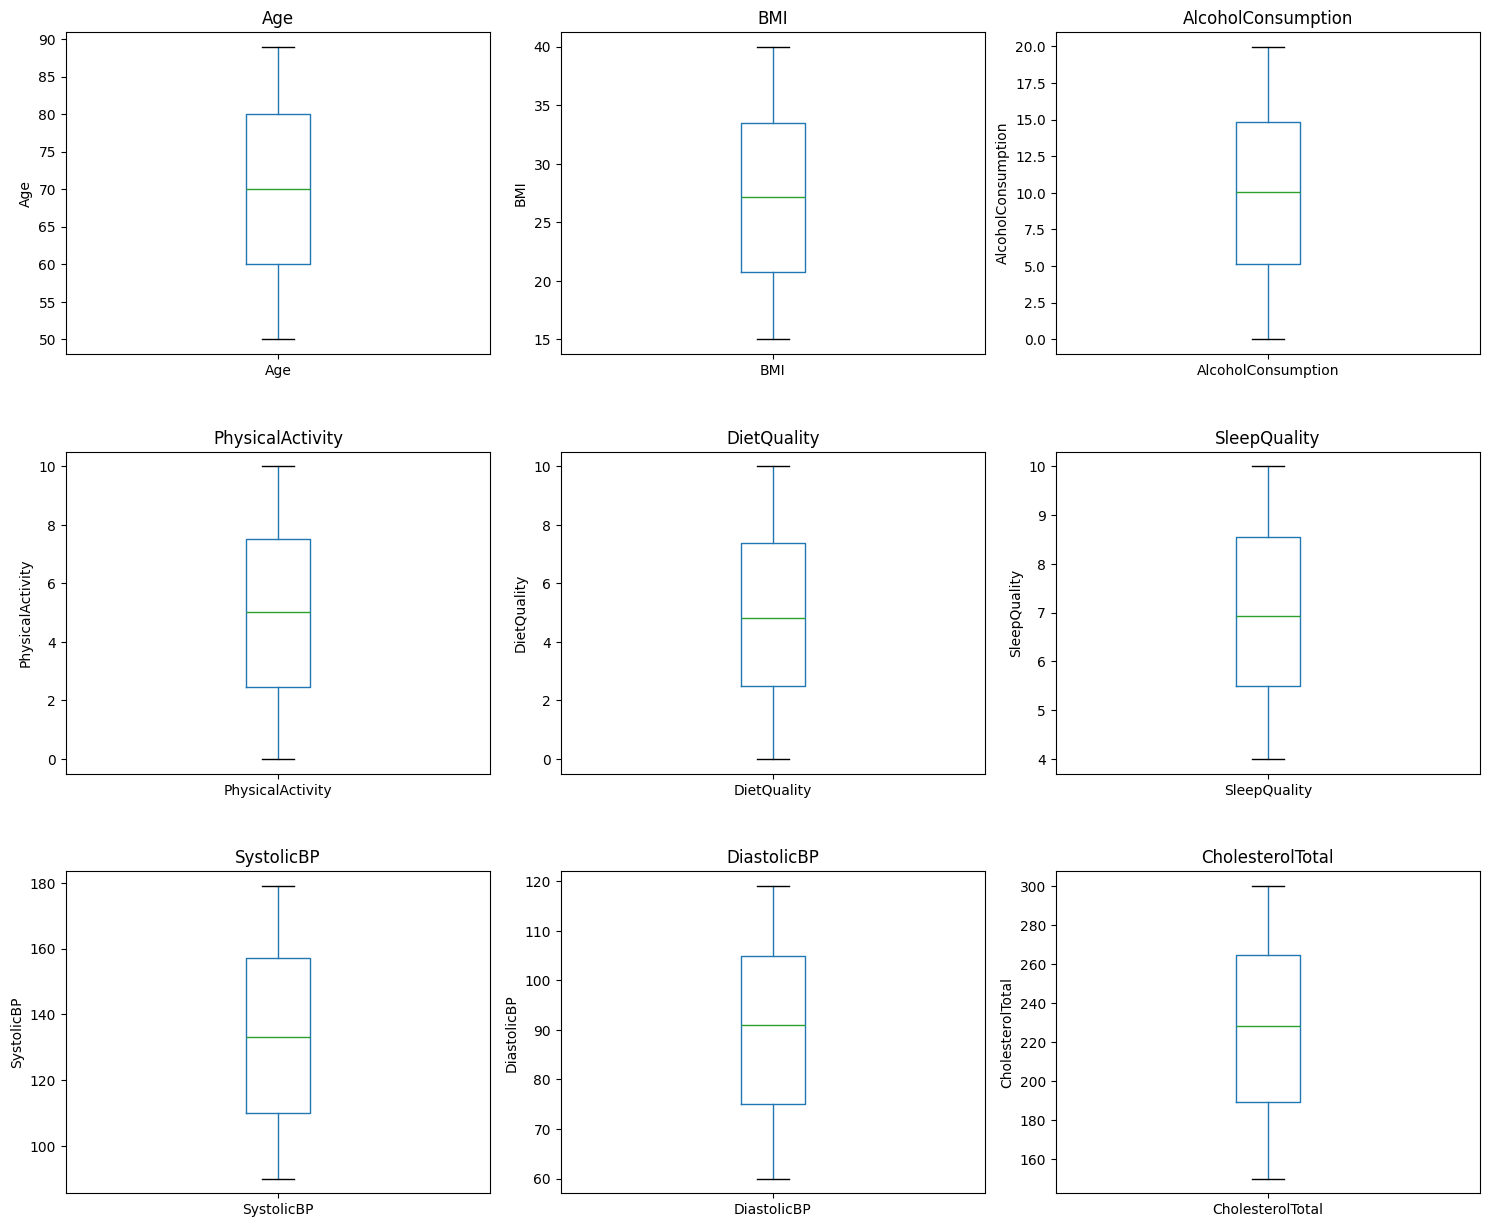

In [ ]:
# Checking for outliers in continuous data

fig,axes = plt.subplots(nrows=3, ncols=3,figsize=(15,8))


#plotting boxplots
for i, ax in enumerate(axes.ravel()):
  df.boxplot(continuous[i], grid=False, ax=ax)
  ax.set_title(f"{continuous[i]}")
  ax.set_ylabel(continuous[i])


fig.tight_layout()
plt.subplots_adjust(top=1.5)
plt.show()

In [ ]:
df.corr()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis
Age,1.000000,0.008675,0.020966,0.015130,0.035622,-0.007591,-0.009016,0.028100,0.012580,0.020866,...,-0.040081,0.039672,0.031264,-0.013883,-0.006975,-0.019534,-0.003485,0.019952,-0.028810,0.065344
Gender,0.008675,1.000000,-0.021080,-0.011429,0.072500,-0.038296,-0.020645,-0.002626,-0.005765,-0.014885,...,0.039508,0.032247,0.019554,0.028244,-0.021746,-0.021580,0.002235,-0.022533,-0.043462,0.016835
Ethnicity,0.020966,-0.021080,1.000000,0.029189,-0.003830,0.052649,0.021406,0.011913,-0.027598,-0.011927,...,0.007343,-0.017035,-0.010136,-0.032114,0.028381,0.032525,-0.018815,-0.002642,-0.013363,-0.005068
EducationLevel,0.015130,-0.011429,0.029189,1.000000,0.008032,-0.005192,-0.000339,-0.011574,0.026629,0.023454,...,-0.027360,-0.020562,-0.004924,0.012890,0.006020,-0.009958,0.020402,-0.012383,0.006028,0.004557
BMI,0.035622,0.072500,-0.003830,0.008032,1.000000,-0.008026,0.015542,-0.003622,0.008020,0.017669,...,-0.017810,-0.004586,0.003343,-0.042454,-0.010259,0.008835,-0.011635,0.047169,-0.020104,0.030114
Smoking,-0.007591,-0.038296,0.052649,-0.005192,-0.008026,1.000000,-0.032095,-0.031046,0.034870,0.009966,...,-0.021843,-0.004500,0.034733,0.003101,-0.024475,0.022392,0.015767,0.029112,0.008485,0.005241
AlcoholConsumption,-0.009016,-0.020645,0.021406,-0.000339,0.015542,-0.032095,1.000000,0.004530,0.007507,0.005871,...,-0.009050,0.002637,0.013162,-0.014867,0.062642,0.007900,0.001887,-0.013234,-0.001646,0.036699
PhysicalActivity,0.028100,-0.002626,0.011913,-0.011574,-0.003622,-0.031046,0.004530,1.000000,-0.017340,-0.007859,...,-0.029015,0.010416,-0.030366,0.014713,0.017127,0.030633,-0.050550,-0.006789,-0.017576,0.012940
DietQuality,0.012580,-0.005765,-0.027598,0.026629,0.008020,0.034870,0.007507,-0.017340,1.000000,0.041904,...,-0.008086,0.032041,-0.008994,-0.003330,-0.010982,-0.014747,-0.007910,0.015327,-0.007378,-0.022992
SleepQuality,0.020866,-0.014885,-0.011927,0.023454,0.017669,0.009966,0.005871,-0.007859,0.041904,1.000000,...,-0.011037,0.031218,0.002998,0.027758,-0.004400,-0.023170,-0.005128,0.013095,-0.001223,-0.043295


In [ ]:
#no duplicated rows
df[df.duplicated()]

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis


In [ ]:
df.shape

(2105, 32)

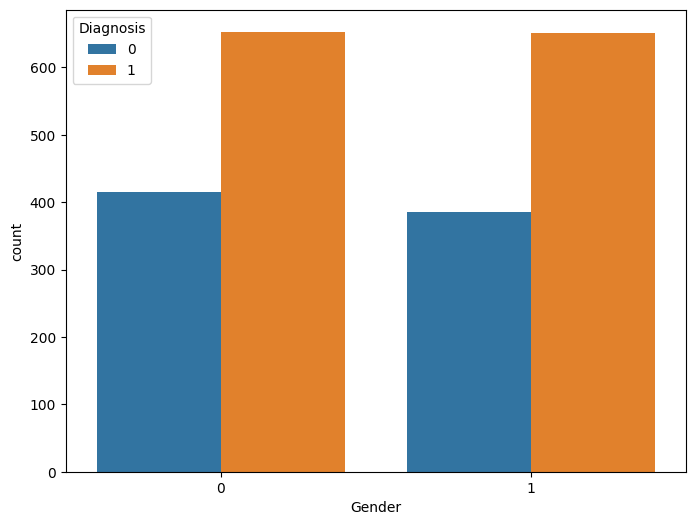

Gender  Diagnosis
0       1            0.611423
        0            0.388577
1       1            0.627772
        0            0.372228
Name: proportion, dtype: float64



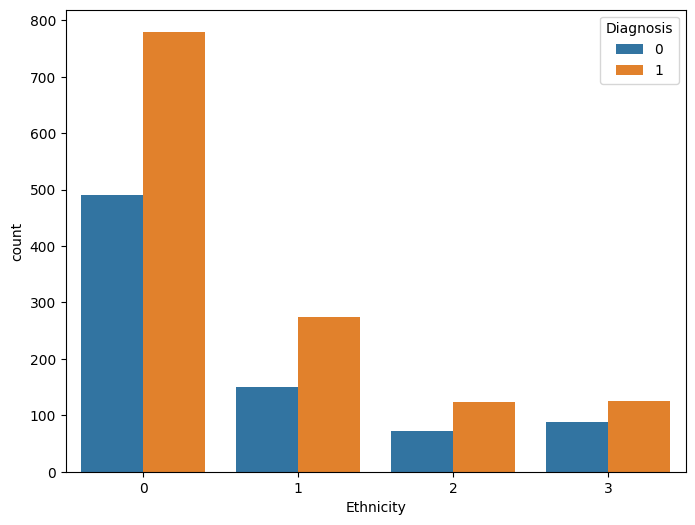

Ethnicity  Diagnosis
0          1            0.614173
           0            0.385827
1          1            0.647059
           0            0.352941
2          1            0.629442
           0            0.370558
3          1            0.586854
           0            0.413146
Name: proportion, dtype: float64



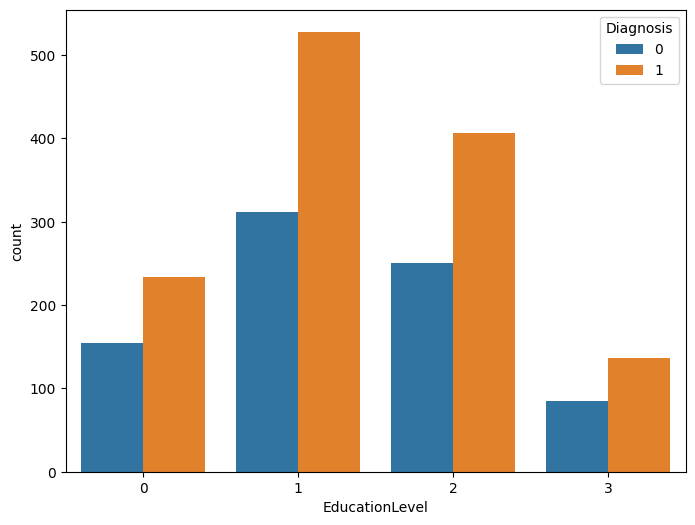

EducationLevel  Diagnosis
0               1            0.603093
                0            0.396907
1               1            0.628571
                0            0.371429
2               1            0.618902
                0            0.381098
3               1            0.615385
                0            0.384615
Name: proportion, dtype: float64



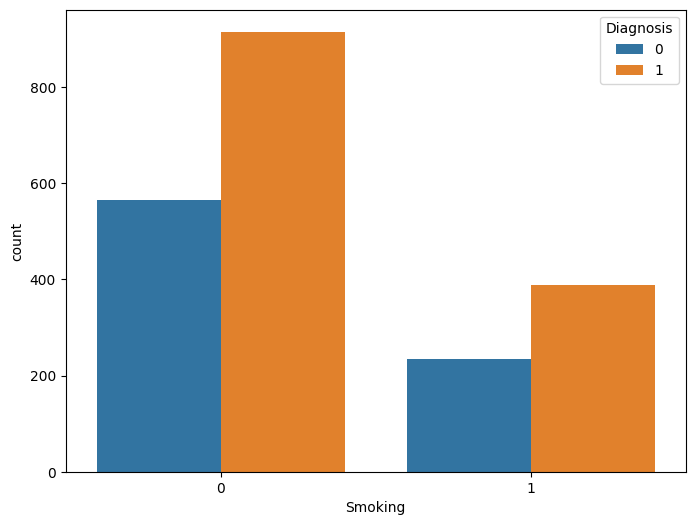

Smoking  Diagnosis
0        1            0.617826
         0            0.382174
1        1            0.623397
         0            0.376603
Name: proportion, dtype: float64



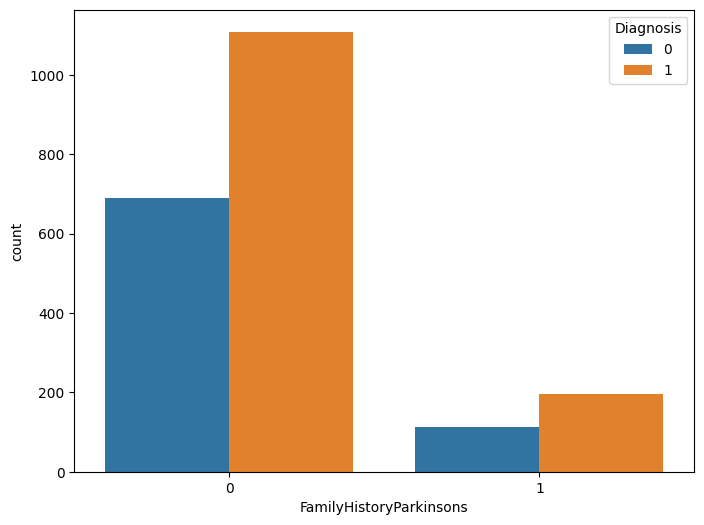

FamilyHistoryParkinsons  Diagnosis
0                        1            0.616796
                         0            0.383204
1                        1            0.635179
                         0            0.364821
Name: proportion, dtype: float64



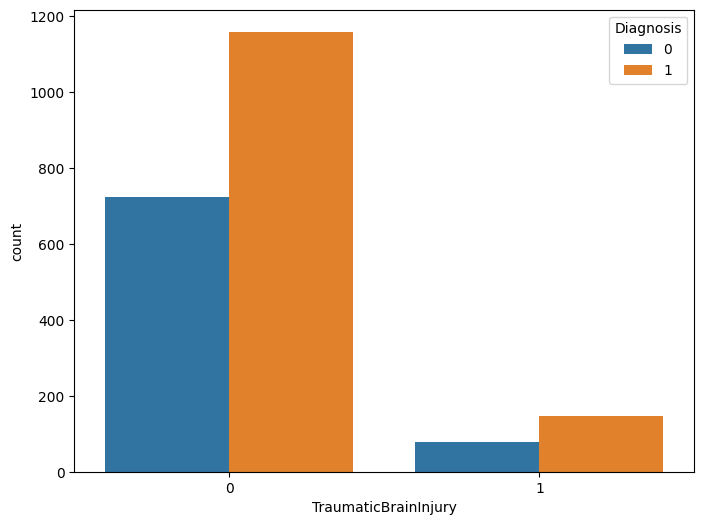

TraumaticBrainInjury  Diagnosis
0                     1            0.615630
                      0            0.384370
1                     1            0.651786
                      0            0.348214
Name: proportion, dtype: float64



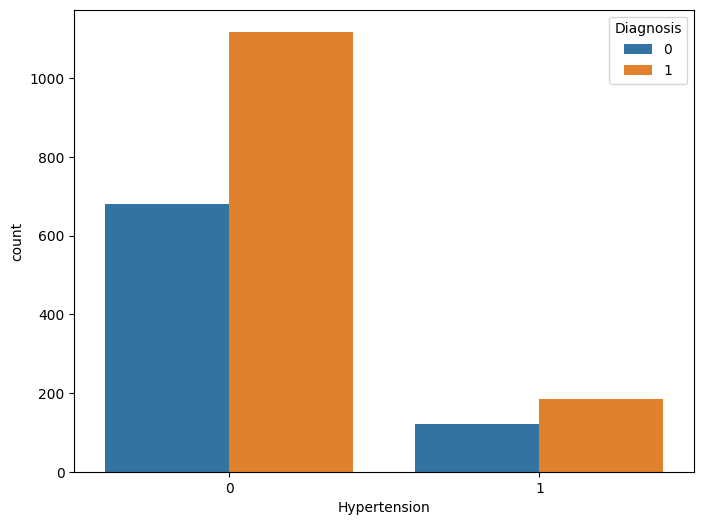

Hypertension  Diagnosis
0             1            0.621802
              0            0.378198
1             1            0.605863
              0            0.394137
Name: proportion, dtype: float64



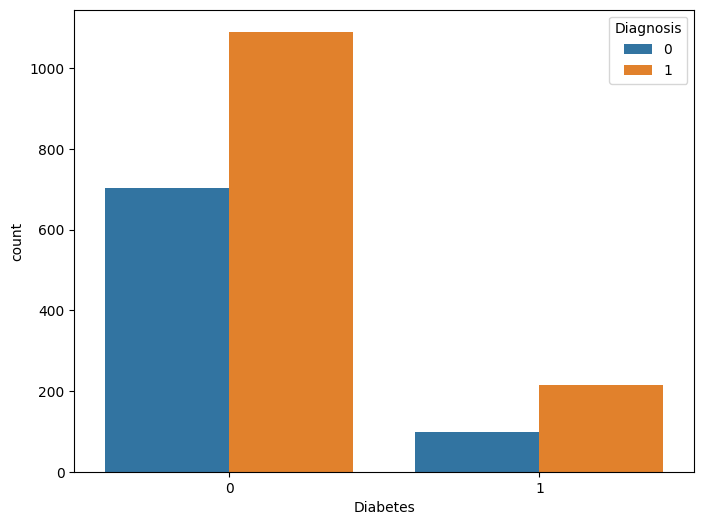

Diabetes  Diagnosis
0         1            0.607920
          0            0.392080
1         1            0.685897
          0            0.314103
Name: proportion, dtype: float64



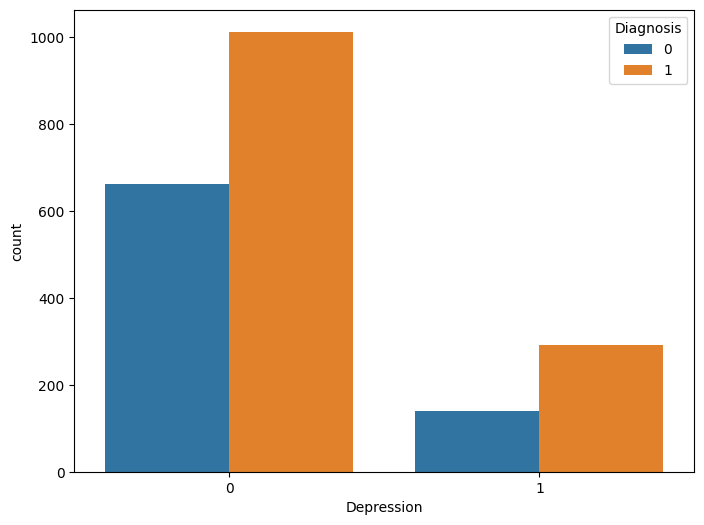

Depression  Diagnosis
0           1            0.604901
            0            0.395099
1           1            0.675926
            0            0.324074
Name: proportion, dtype: float64



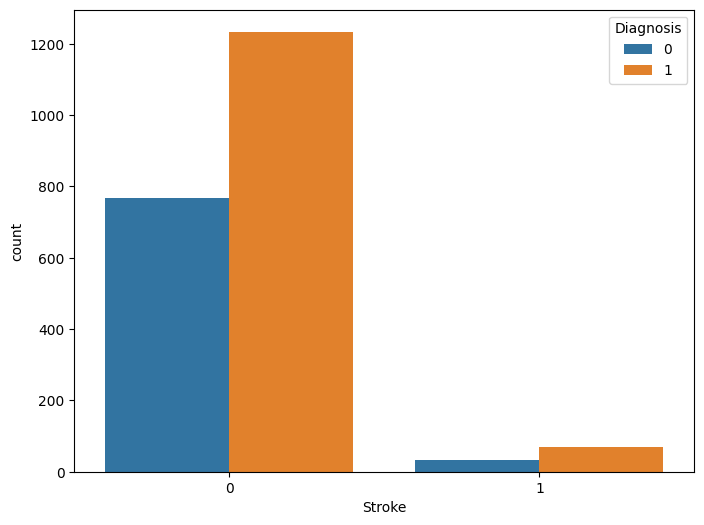

Stroke  Diagnosis
0       1            0.616384
        0            0.383616
1       1            0.679612
        0            0.320388
Name: proportion, dtype: float64



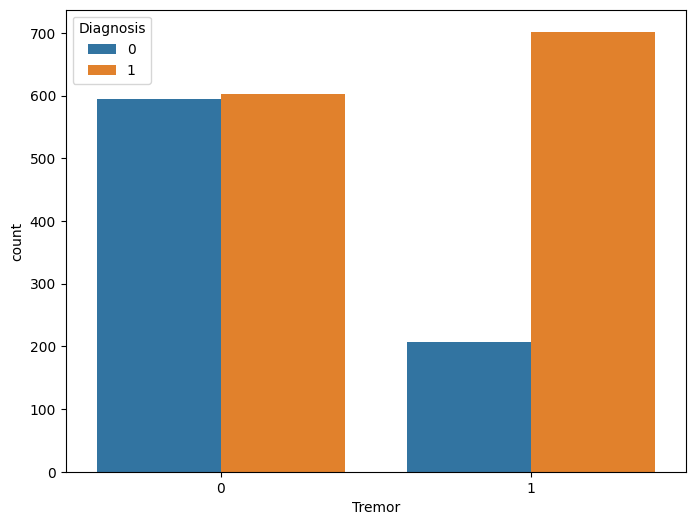

Tremor  Diagnosis
0       1            0.503344
        0            0.496656
1       1            0.772277
        0            0.227723
Name: proportion, dtype: float64



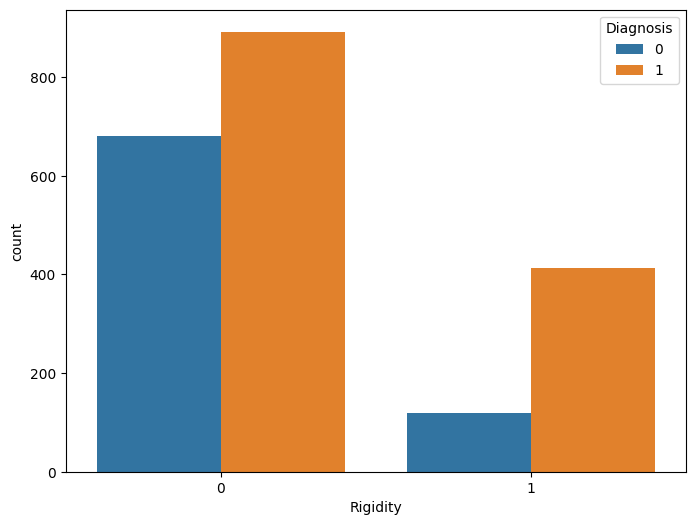

Rigidity  Diagnosis
0         1            0.567069
          0            0.432931
1         1            0.774436
          0            0.225564
Name: proportion, dtype: float64



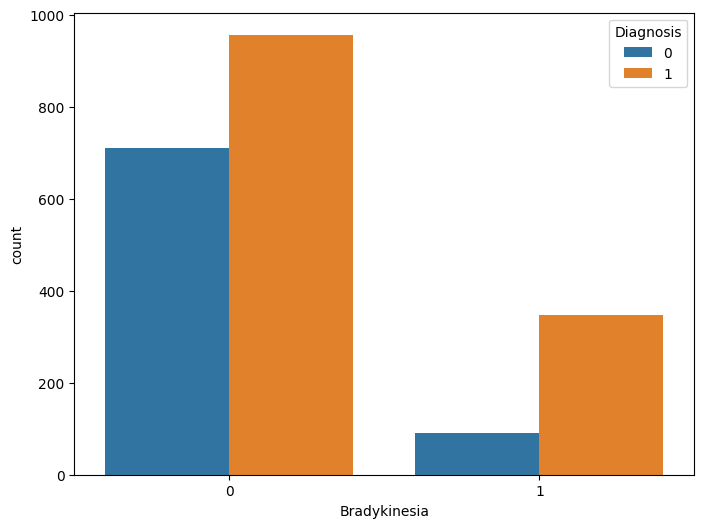

Bradykinesia  Diagnosis
0             1            0.573741
              0            0.426259
1             1            0.794050
              0            0.205950
Name: proportion, dtype: float64



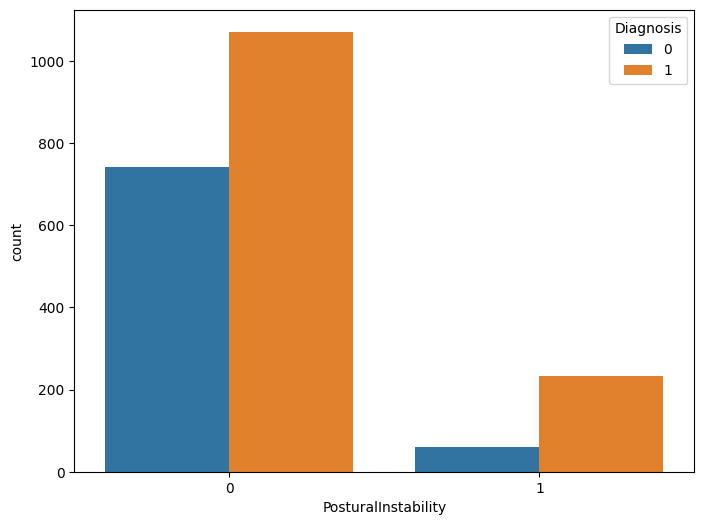

PosturalInstability  Diagnosis
0                    1            0.590734
                     0            0.409266
1                    1            0.797945
                     0            0.202055
Name: proportion, dtype: float64



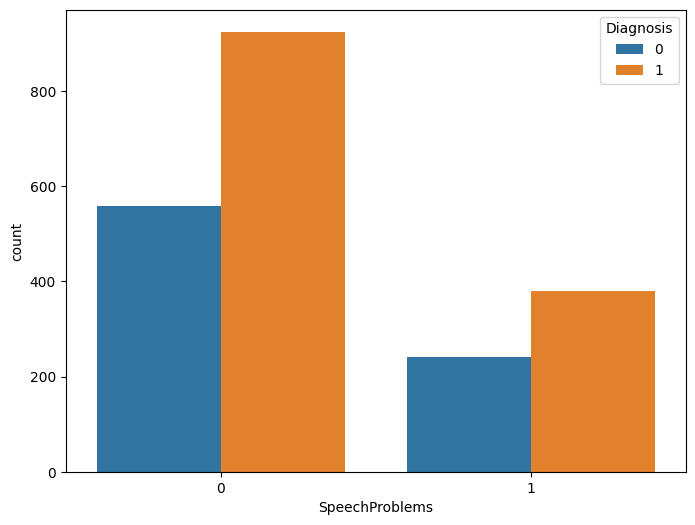

SpeechProblems  Diagnosis
0               1            0.623315
                0            0.376685
1               1            0.610306
                0            0.389694
Name: proportion, dtype: float64



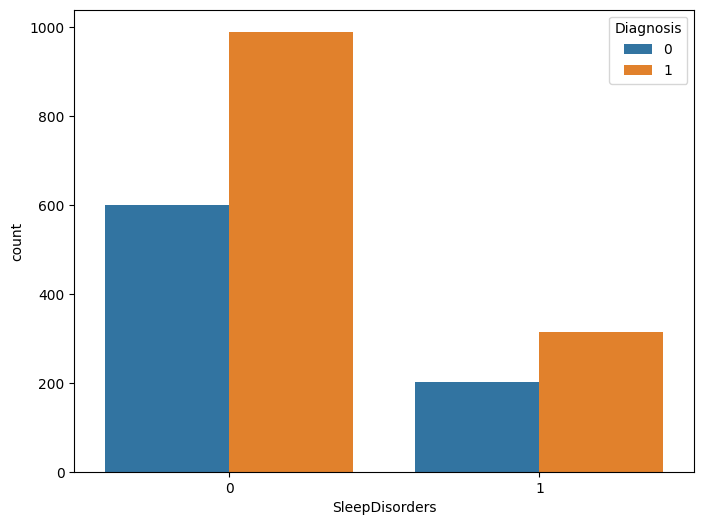

SleepDisorders  Diagnosis
0               1            0.622404
                0            0.377596
1               1            0.610465
                0            0.389535
Name: proportion, dtype: float64



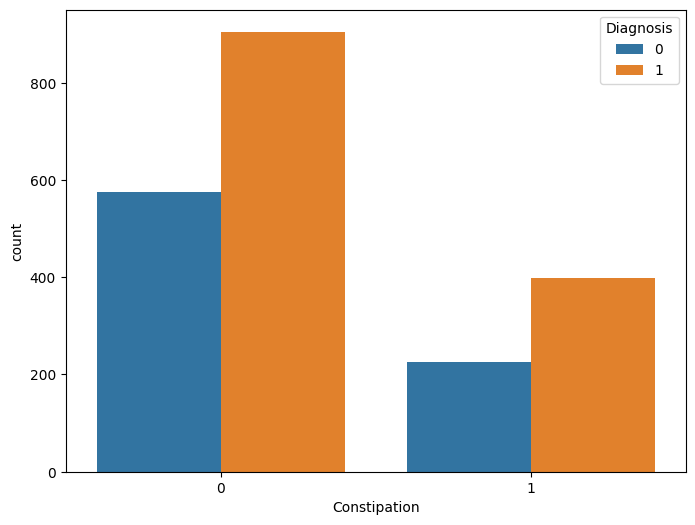

Constipation  Diagnosis
0             1            0.611486
              0            0.388514
1             1            0.638400
              0            0.361600
Name: proportion, dtype: float64



In [ ]:
for col in categorical:
  ax = sns.countplot(x=col, hue = 'Diagnosis', data=df)
  plt.gcf().set_size_inches(8, 6)

  plt.show()
  print(df.groupby([col])['Diagnosis'].value_counts(normalize=True))
  print('')

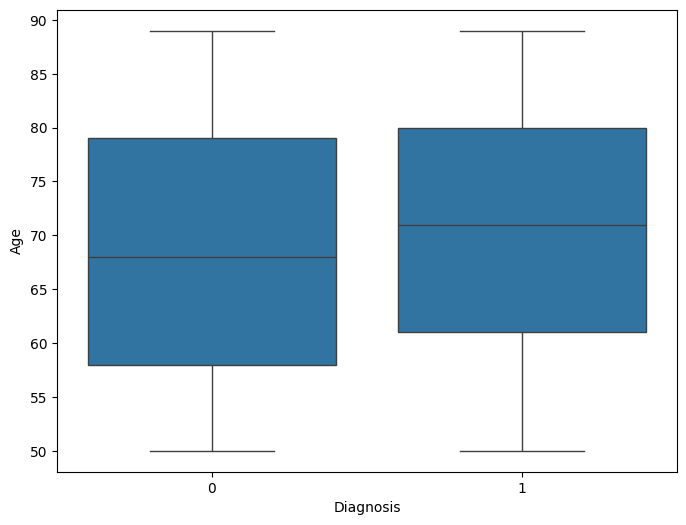

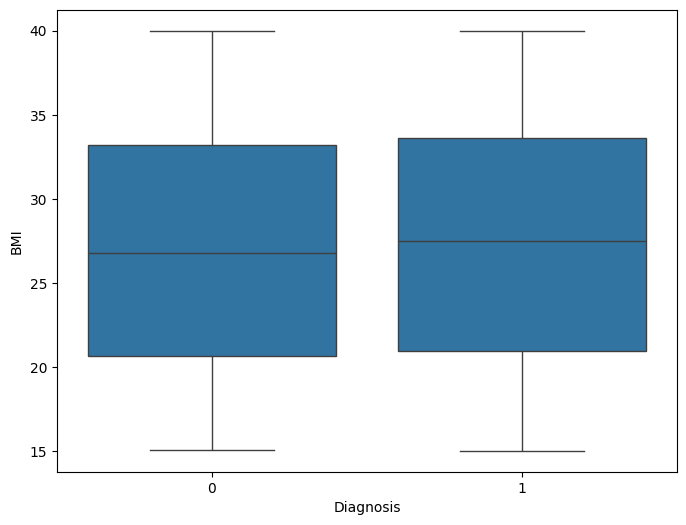

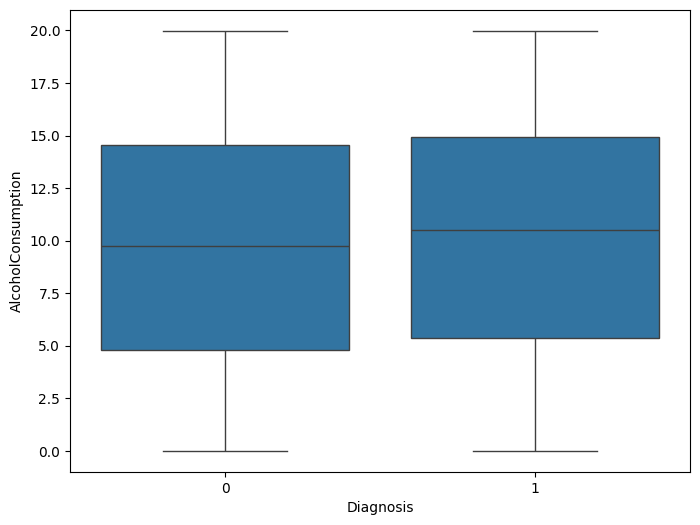

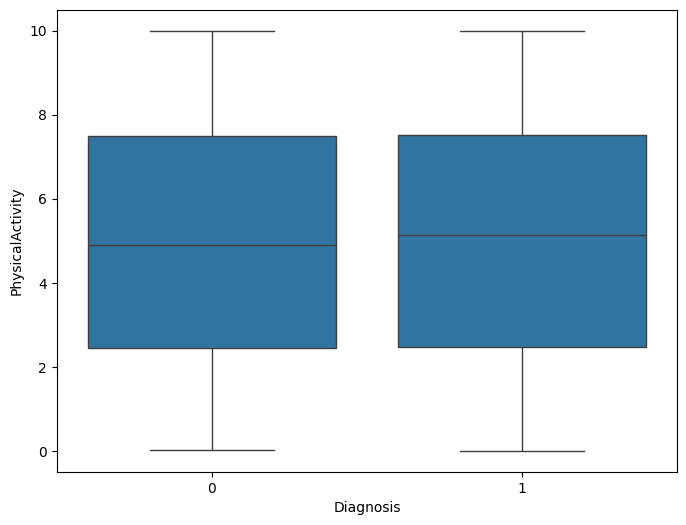

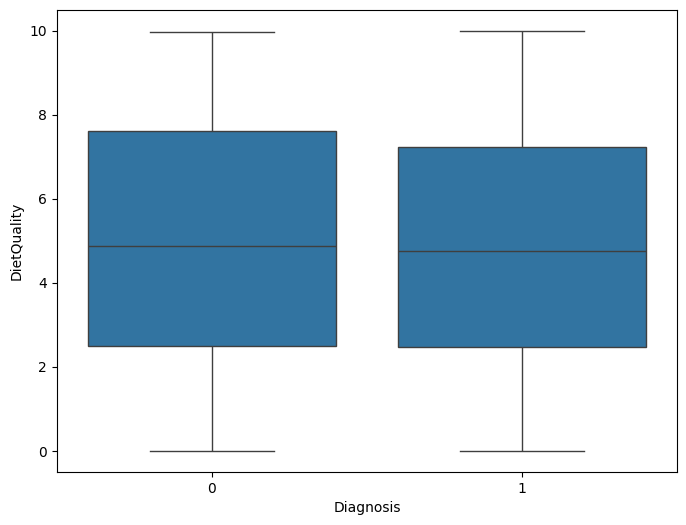

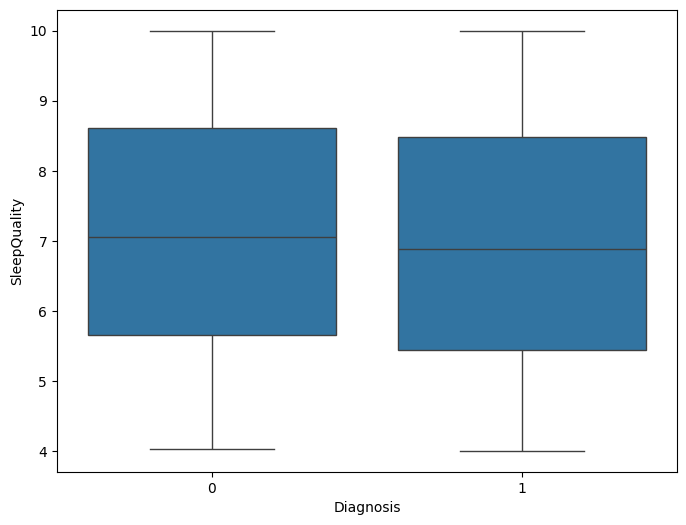

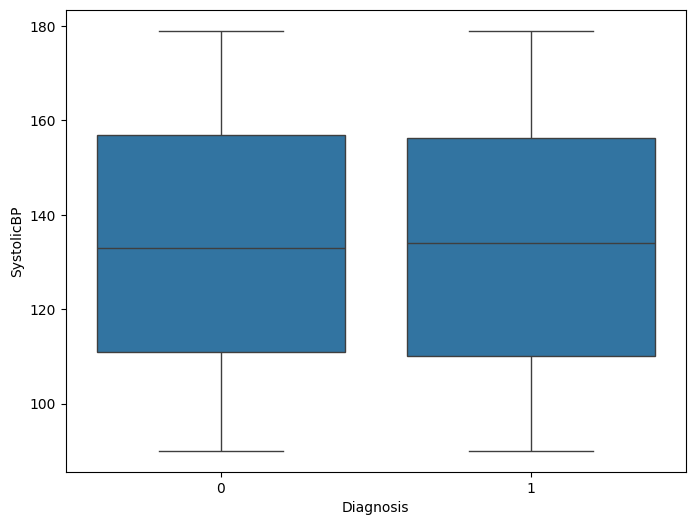

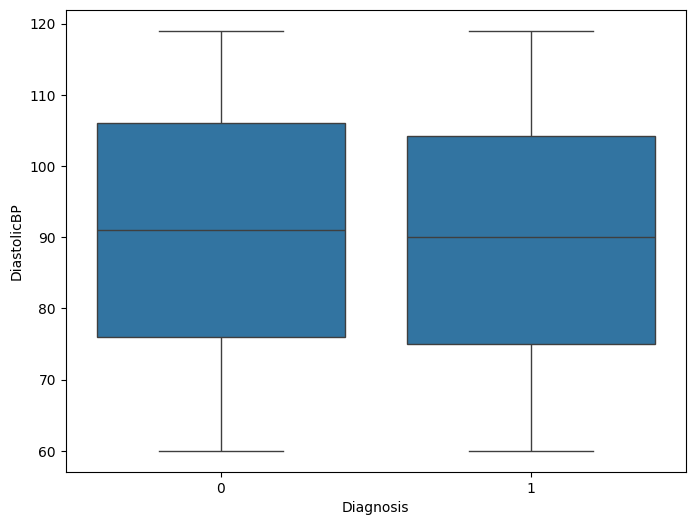

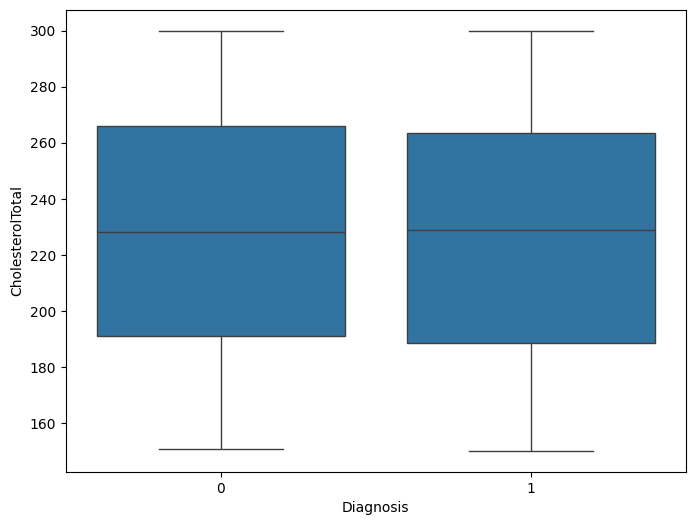

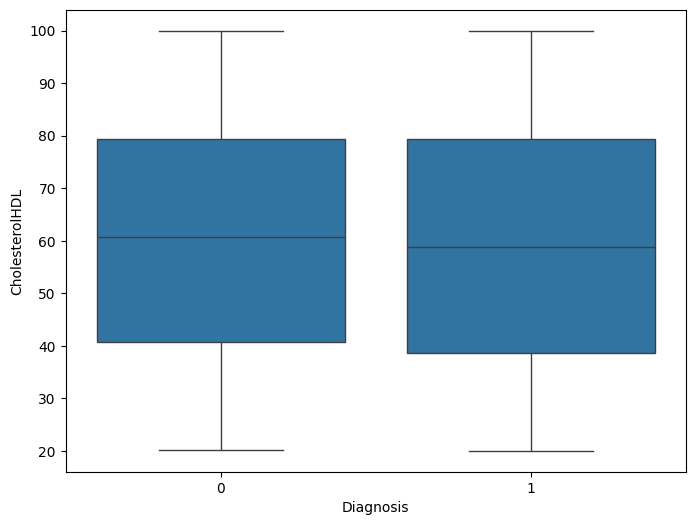

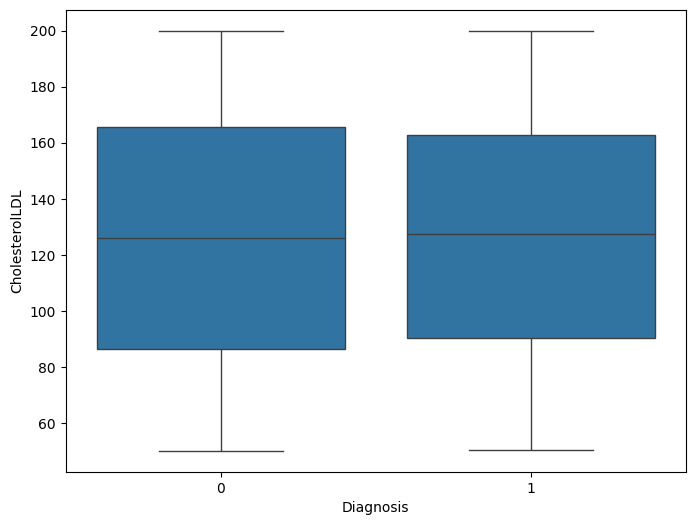

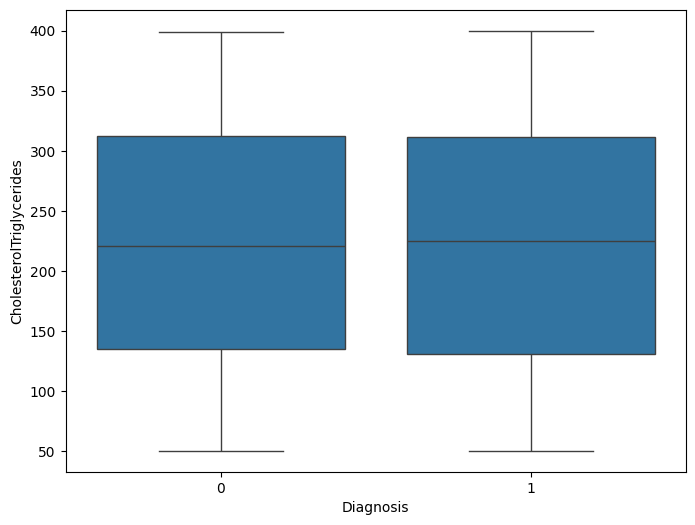

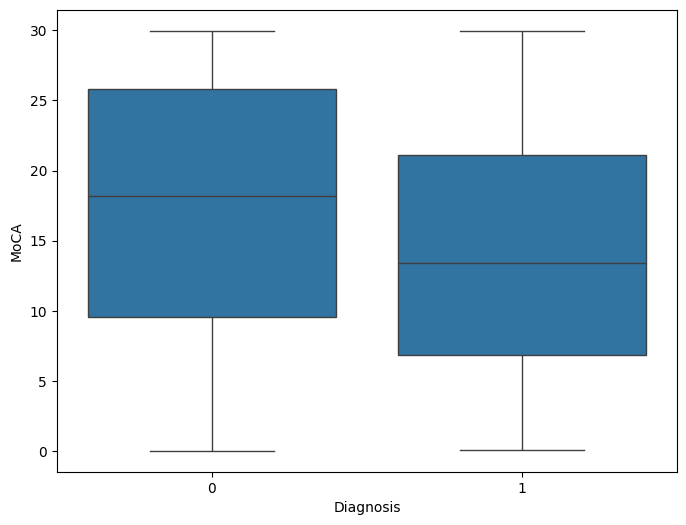

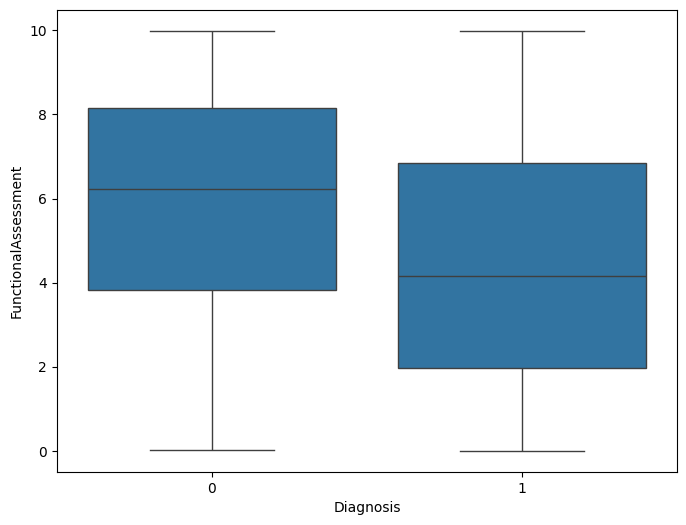

In [ ]:
for col in continuous:
  ax = sns.boxplot(x='Diagnosis', y=col, data=df)
  plt.gcf().set_size_inches(8, 6)

  plt.show()

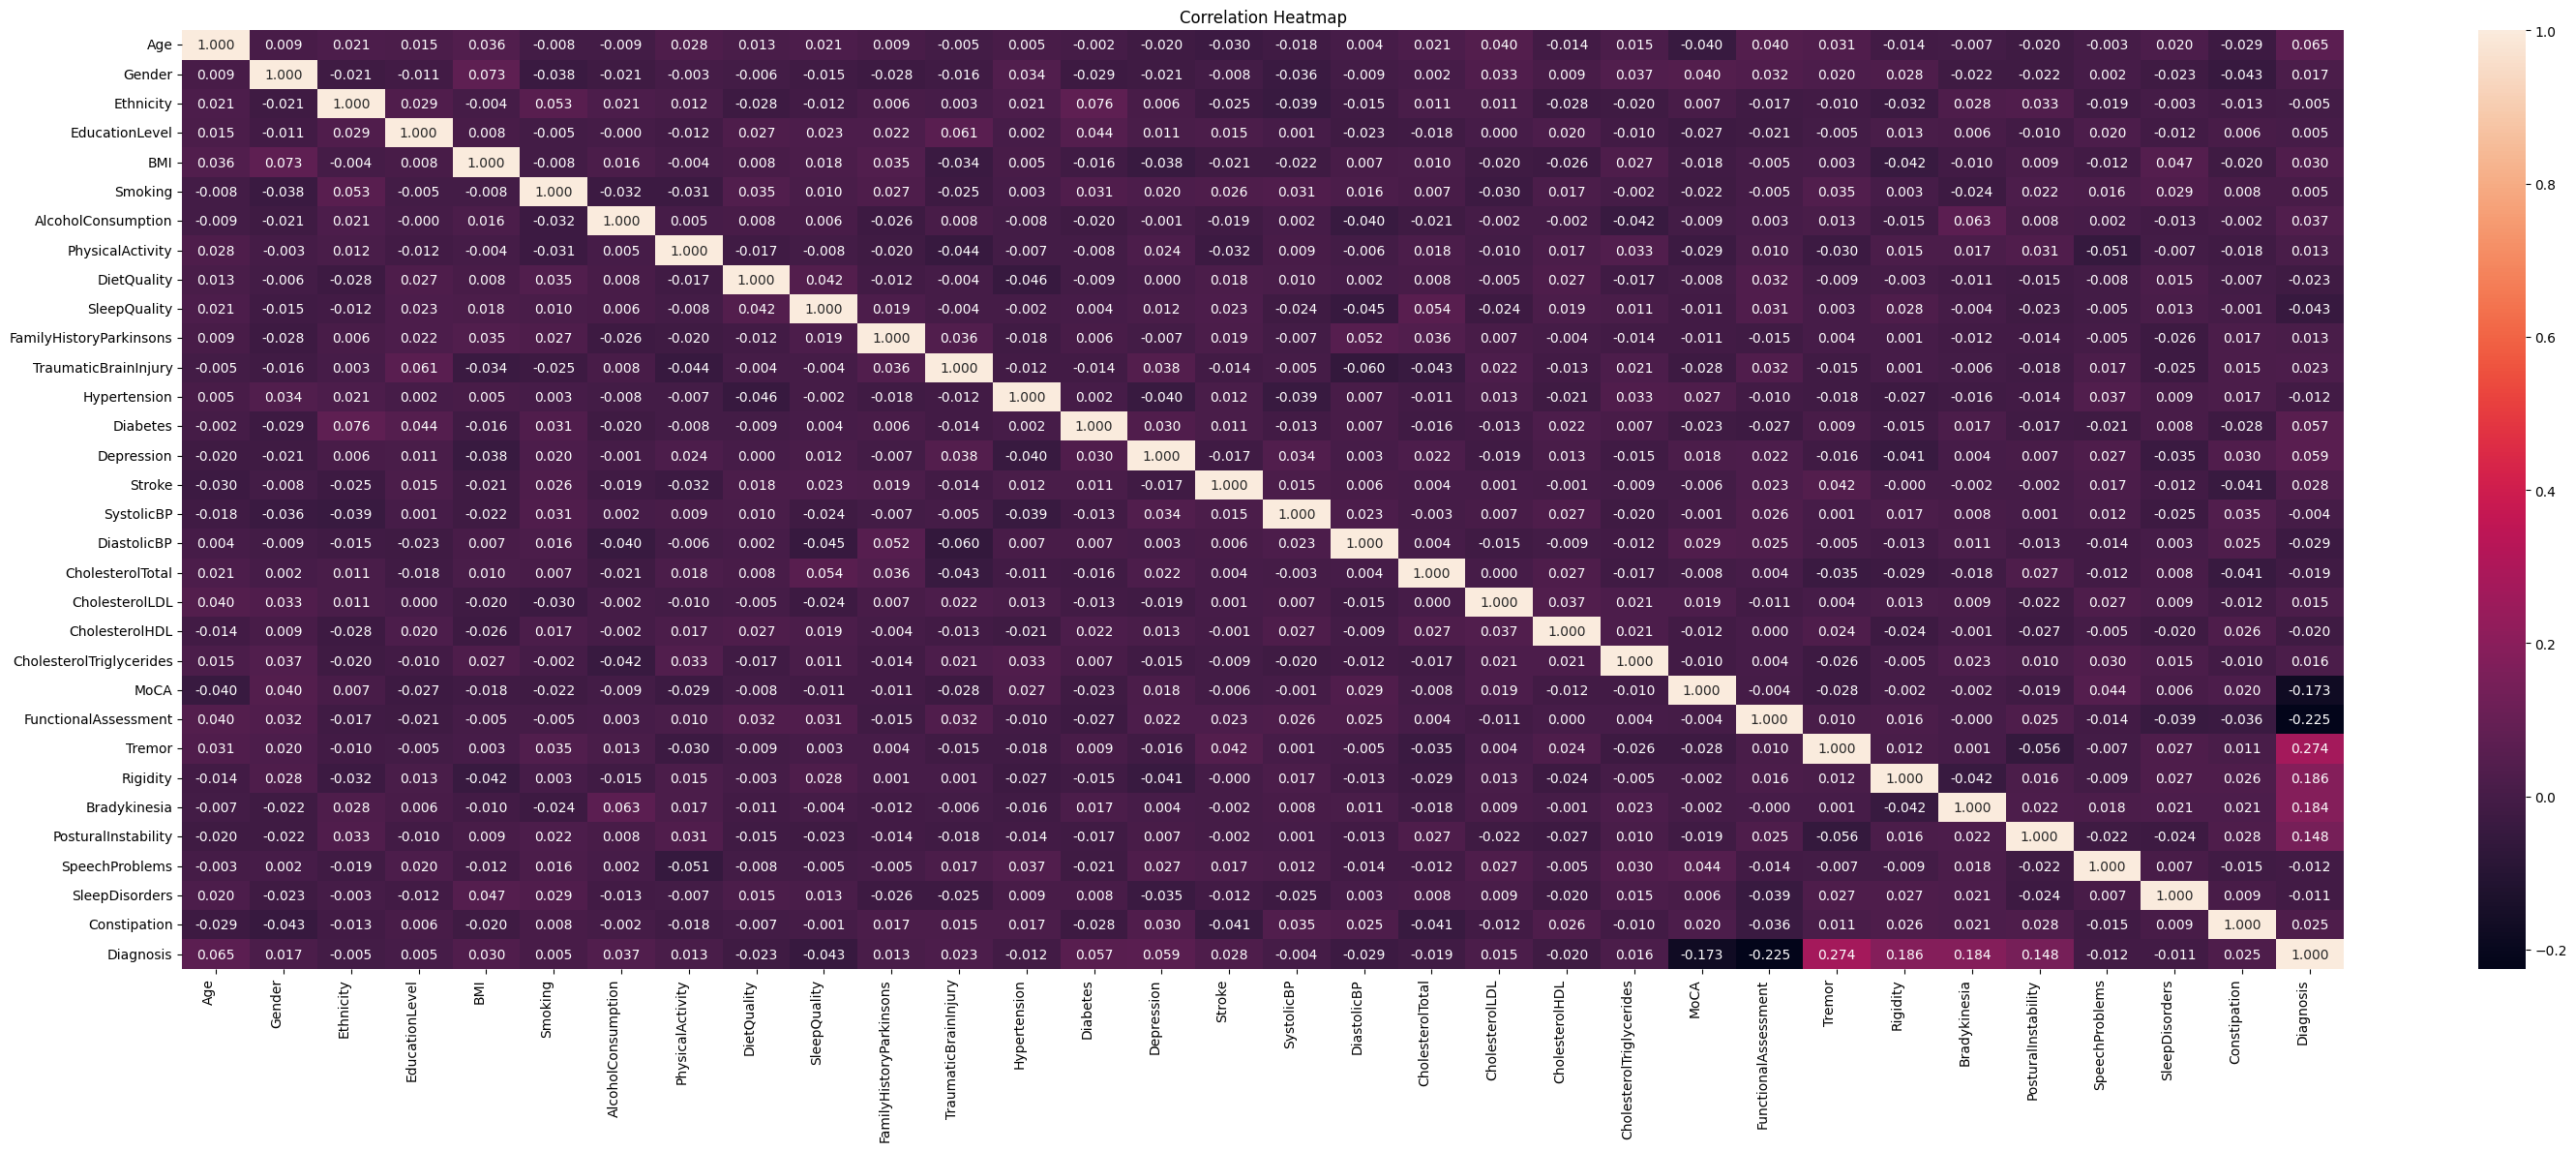

In [ ]:
fig, ax = plt.subplots(figsize=(30, 12)) # Create a figure and an axes object
sns.heatmap(df.corr(), annot=True, fmt='.3f', ax=ax)

# Adjust x-axis tick labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=10)

# Adjust y-axis tick labels
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center', fontsize=10)

plt.title('Correlation Heatmap')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [ ]:
X = df.drop(columns=['Diagnosis'])
y = df['Diagnosis']

In [ ]:
X.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,CholesterolTriglycerides,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation
0,85,0,3,1,19.619878,0,5.108241,1.380660,3.893969,9.283194,...,337.307114,29.181289,1.572427,1,0,0,0,0,0,0
1,75,0,0,2,16.247339,1,6.027648,8.409804,8.513428,5.602470,...,264.635521,12.332639,4.787551,0,1,0,1,0,1,0
2,70,1,0,0,15.368239,0,2.242135,0.213275,6.498805,9.929824,...,395.662649,29.927783,2.130686,1,0,0,0,1,0,1
3,52,0,0,0,15.454557,0,5.997788,1.375045,6.715033,4.196189,...,362.189688,21.304268,3.391288,1,1,1,0,0,0,1
4,87,0,0,1,18.616042,0,9.775243,1.188607,4.657572,9.363925,...,149.956586,8.336364,3.200969,0,0,0,1,0,1,0


In [ ]:
y.head()

,Diagnosis
0,0
1,1
2,1
3,1
4,0


In [ ]:
# for col in df_std.columns:
#     print(col)
#     print(f"Mean: {round(df_std[col].mean(), 2)}")
#     print(f"Standard deviation: {round(df_std[col].std(), 2)}")
#     print(f"Range: {round(df_std[col].max()-df_std[col].min(), 2)}")
#     print()

In [ ]:
terms = df.drop(columns=['Diagnosis']).columns
terms

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryParkinsons', 'TraumaticBrainInjury', 'Hypertension',
       'Diabetes', 'Depression', 'Stroke', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MoCA', 'FunctionalAssessment', 'Tremor',
       'Rigidity', 'Bradykinesia', 'PosturalInstability', 'SpeechProblems',
       'SleepDisorders', 'Constipation'],
      dtype='object')

In [ ]:
#stratified train test split to get the test set that will remain untouched and tested on final model as unbiased estimate
X_train_unsc, X_test_fin_unsc, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#scaling features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_unsc)

X_train = pd.DataFrame(
    X_train,
    columns=X_train_unsc.columns,
    index=X_train_unsc.index
)

#preventing data leakage by not fitting on the unbiased test set
X_test_fin = scaler.transform(X_test_fin_unsc)
X_test_fin = pd.DataFrame(
    X_test_fin,
    columns=X_test_fin_unsc.columns,
    index=X_test_fin_unsc.index
)

In [ ]:
#X_train
# df_std = pd.DataFrame(X_scaled, columns=X.columns)
# df_std['Diagnosis'] = y
# df_std.head()

In [ ]:
X_train.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,CholesterolTriglycerides,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation
1700,-1.182675,-0.970737,-0.688642,-0.377437,1.518932,-0.651693,0.768291,0.009098,0.784252,1.036426,...,-0.449776,0.754879,1.167276,-0.873699,-0.583750,-0.516835,-0.400723,1.558761,-0.569122,1.517221
1102,1.237178,1.030145,0.311076,-0.377437,0.926410,-0.651693,0.969844,1.496181,-1.039368,-0.471761,...,0.143216,-0.839814,-1.662296,1.144558,-0.583750,-0.516835,-0.400723,-0.641535,-0.569122,-0.659100
508,-1.441945,-0.970737,0.311076,-0.377437,0.406023,-0.651693,-0.722797,0.319099,-1.177827,0.895068,...,1.165532,0.320770,0.352029,-0.873699,-0.583750,-0.516835,-0.400723,-0.641535,-0.569122,-0.659100
679,1.582871,1.030145,0.311076,0.743558,-1.000766,-0.651693,-0.480765,1.631347,1.391411,-0.371378,...,1.490209,1.579368,0.285203,-0.873699,1.713061,-0.516835,-0.400723,-0.641535,-0.569122,-0.659100
1000,0.632214,-0.970737,1.310794,0.743558,0.748667,-0.651693,-0.705950,-0.573692,1.345225,-1.325735,...,1.592260,1.677038,-1.023176,1.144558,1.713061,1.934855,-0.400723,-0.641535,-0.569122,-0.659100


In [ ]:
X_test_fin.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,CholesterolTriglycerides,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation
194,-0.750559,-0.970737,0.311076,0.743558,-1.610216,-0.651693,-0.937456,1.698334,-0.928595,1.230378,...,1.063465,-1.135687,-0.136990,-0.873699,-0.583750,-0.516835,-0.400723,-0.641535,-0.569122,-0.659100
1879,-0.404866,-0.970737,-0.688642,-0.377437,1.731795,1.534465,-1.182977,-0.964779,0.594393,-0.143414,...,-0.908917,0.413645,1.625785,-0.873699,1.713061,-0.516835,-0.400723,1.558761,-0.569122,1.517221
136,-1.355522,1.030145,-0.688642,-1.498432,-0.379680,-0.651693,0.700988,-0.595346,0.342635,0.035883,...,-0.406435,-1.311961,0.620698,1.144558,-0.583750,1.934855,-0.400723,-0.641535,-0.569122,1.517221
1522,-1.614792,-0.970737,0.311076,-1.498432,1.754671,-0.651693,1.468099,0.290653,-0.684652,-0.286583,...,1.310730,1.574582,-1.218604,-0.873699,-0.583750,1.934855,-0.400723,-0.641535,-0.569122,1.517221
326,0.891484,1.030145,-0.688642,-0.377437,-1.582046,1.534465,-0.374812,-0.102589,0.669840,-0.420464,...,-0.208852,-0.476387,1.657205,1.144558,1.713061,-0.516835,-0.400723,1.558761,-0.569122,-0.659100


In [ ]:
y_train.value_counts(normalize=True)

,proportion
Diagnosis,
1,0.619359
0,0.380641


In [ ]:
#x_train will be used for cross validation later with logistic regression (after feature selection)
#these first steps are for exploratory purposes.

#as an exploratory step:
#this needs a validation test set for the single model predictor summary table along with p values. will split x_train.
#original X test will only be used for evaluating performance of best models of each model type after feature selection and modeling

X_trainlog, X_val, y_trainlog, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [ ]:
#one predictor at a time, fitting on trainlog and evaluating on val sets noting accuracy, precision, recall
#and f1 score, as well as p-value of each predictor

results_df = pd.DataFrame(columns=[
    'predictor', 'accuracy', 'precision', 'recall', 'f1', 'pvalue'
])

# list of predictors


for col in terms:
    design = MS([col])
    X_tr = design.fit_transform(X_trainlog)
    X_va = design.transform(X_val)


    y_tr = y_trainlog
    y_va = y_val

    #logistic regression
    glm = sm.GLM(
        y_tr,
        X_tr,
        family=sm.families.Binomial()
    )

    results = glm.fit()

    pval = results.pvalues[col]

    probs = results.predict(X_va)
    y_pred = (probs >= 0.5)

    # metrics
    acc = accuracy_score(y_va, y_pred)
    prec = precision_score(y_va, y_pred)
    rec = recall_score(y_va, y_pred)
    f1 = f1_score(y_va, y_pred)


    results_df.loc[len(results_df)] = [
        col, acc, prec, rec, f1, pval
    ]
    # print(col)
    # print(np.unique(y_pred, return_counts=True))
    # print("prob range:", probs.min(), probs.max())


results_df = results_df.sort_values(by='pvalue', ascending=True)

results_df


,predictor,accuracy,precision,recall,f1,pvalue
24,Tremor,0.620178,0.620178,1.000000,0.765568,1.421069e-21
23,FunctionalAssessment,0.617211,0.648148,0.837321,0.730689,3.685677e-14
26,Bradykinesia,0.620178,0.620178,1.000000,0.765568,1.486073e-10
27,PosturalInstability,0.620178,0.620178,1.000000,0.765568,2.393436e-09
25,Rigidity,0.620178,0.620178,1.000000,0.765568,3.314428e-09
22,MoCA,0.623145,0.625767,0.976077,0.762617,7.316663e-08
0,Age,0.620178,0.620178,1.000000,0.765568,9.047270e-03
13,Diabetes,0.620178,0.620178,1.000000,0.765568,4.483943e-02
14,Depression,0.620178,0.620178,1.000000,0.765568,4.714348e-02
18,CholesterolTotal,0.620178,0.620178,1.000000,0.765568,5.380581e-02


In [ ]:
#significant p values single predictors
results_df[results_df['pvalue'] < 0.05][['predictor','pvalue']]

,predictor,pvalue
24,Tremor,1.421069e-21
23,FunctionalAssessment,3.685677e-14
26,Bradykinesia,1.486073e-10
27,PosturalInstability,2.393436e-09
25,Rigidity,3.314428e-09
22,MoCA,7.316663e-08
0,Age,9.047270e-03
13,Diabetes,4.483943e-02
14,Depression,4.714348e-02


Accuracy: 0.7685459940652819
Precision: 0.8195121951219512
Recall: 0.8038277511961722
F1-score: 0.8115942028985508


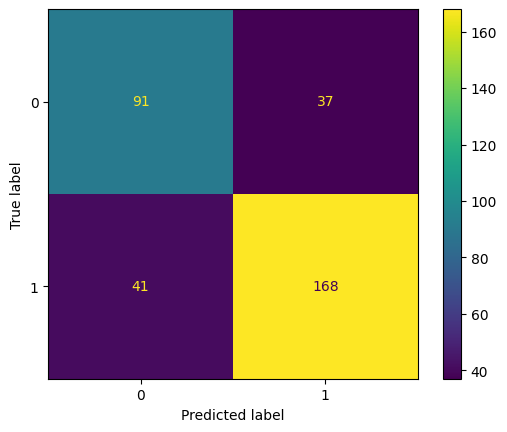

,0
Tremor,4.091145e-29
FunctionalAssessment,4.000255e-21
Bradykinesia,4.465318e-14
Rigidity,4.512477e-14
PosturalInstability,1.225211e-12
MoCA,1.771207e-09
Depression,4.775189e-04
Age,8.765916e-04
SleepQuality,2.604207e-02
Stroke,3.773754e-02


,0
Tremor,4.091145e-29
FunctionalAssessment,4.000255e-21
Bradykinesia,4.465318e-14
Rigidity,4.512477e-14
PosturalInstability,1.225211e-12
MoCA,1.771207e-09
Depression,4.775189e-04
Age,8.765916e-04
SleepQuality,2.604207e-02
Stroke,3.773754e-02


In [ ]:
#all terms fit
design = MS(terms)
X_tr = design.fit_transform(X_trainlog)
X_va = design.transform(X_val)


glm = sm.GLM(
    y_trainlog,
    X_tr,
    family=sm.families.Binomial()
)

results = glm.fit()


probs = results.predict(X_va)
y_pred = (probs >= 0.5)

# metrics
acc = accuracy_score(y_va, y_pred)
prec = precision_score(y_va, y_pred)
rec = recall_score(y_va, y_pred)
f1 = f1_score(y_va, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)


cm = confusion_matrix(y_val, y_pred)

# print("\nConfusion Matrix:")
# print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

display(results.pvalues.drop('intercept').sort_values())

display(results.pvalues[results.pvalues< 0.05].drop('intercept').sort_values())


Accuracy: 0.7685459940652819
Precision: 0.8195121951219512
Recall: 0.8038277511961722
F1: 0.8115942028985508


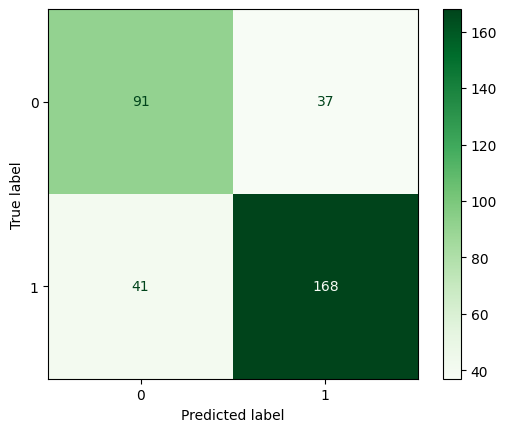

,0
Tremor_sq,9.854438e-33
Tremor,5.634974e-24
FunctionalAssessment,4.000201e-21
Bradykinesia,4.465279e-14
Rigidity,4.512440e-14
PosturalInstability,1.225200e-12
MoCA,1.771200e-09
Depression,4.775183e-04
Age,8.765906e-04
SleepQuality,2.604206e-02


,0
Tremor_sq,9.854438e-33
Tremor,5.634974e-24
FunctionalAssessment,4.000201e-21
Bradykinesia,4.465279e-14
Rigidity,4.512440e-14
PosturalInstability,1.225200e-12
MoCA,1.771200e-09
Depression,4.775183e-04
Age,8.765906e-04
SleepQuality,2.604206e-02


In [ ]:
#nonlinear predictors fit
X_train_poly = X_trainlog.copy()
X_val_poly = X_val.copy()

nonlinear_feature ='Tremor'

X_train_poly[nonlinear_feature + "_sq"] = X_trainlog[nonlinear_feature] ** 2
X_val_poly[nonlinear_feature + "_sq"] = X_val[nonlinear_feature] ** 2


design = MS(X_train_poly.columns)

X_tr = design.fit_transform(X_train_poly)
X_va = design.transform(X_val_poly)


glm = sm.GLM(
    y_trainlog,
    X_tr,
    family=sm.families.Binomial()
)

results = glm.fit()


probs = results.predict(X_va)
y_pred = (probs >= 0.5).astype(int)



print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1:", f1_score(y_val, y_pred))
cm = confusion_matrix(y_val, y_pred)

# print("\nConfusion Matrix:")
# print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')
plt.show()


display(results.pvalues.drop('intercept').sort_values())

display(results.pvalues[results.pvalues< 0.05].drop('intercept').sort_values())


In [ ]:
#tremor_sq had a significant pvalue

Accuracy: 0.771513353115727
Precision: 0.8235294117647058
Recall: 0.8038277511961722
F1-score: 0.8135593220338984


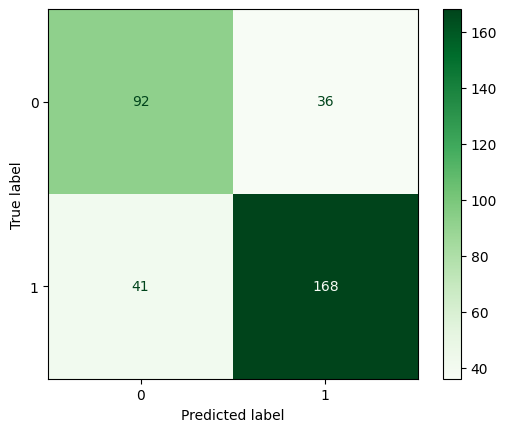


P-values:


,0
Tremor,3.566933e-29
FunctionalAssessment,3.331470e-21
Bradykinesia,3.725526e-14
Rigidity,4.425704e-14
PosturalInstability,9.799062e-13
MoCA,2.000164e-09
Depression,4.625022e-04
Age,8.766423e-04
Stroke,3.580612e-02
SleepQuality,3.612832e-02


,0
Tremor,3.566933e-29
FunctionalAssessment,3.331470e-21
Bradykinesia,3.725526e-14
Rigidity,4.425704e-14
PosturalInstability,9.799062e-13
MoCA,2.000164e-09
Depression,4.625022e-04
Age,8.766423e-04
Stroke,3.580612e-02
SleepQuality,3.612832e-02


In [ ]:
#some interactions

X_train_int = X_trainlog.copy()
X_val_int = X_val.copy()

# choose two predictors (you can change these)
x1 = 'SleepQuality'
x2 = 'PosturalInstability'

interaction_name = f"{x1}_x_{x2}"

X_train_int[interaction_name] = X_trainlog[x1] * X_trainlog[x2]
X_val_int[interaction_name] = X_val[x1] * X_val[x2]


design = MS(X_train_int.columns)

X_tr = design.fit_transform(X_train_int)
X_va = design.transform(X_val_int)


glm = sm.GLM(
    y_trainlog,
    X_tr,
    family=sm.families.Binomial()
)

results = glm.fit()


probs = results.predict(X_va)
y_pred = (probs >= 0.5).astype(int)


acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

cm = confusion_matrix(y_val, y_pred)

# print("\nConfusion Matrix:")
# print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')
plt.show()

print("\nP-values:")
#print(results.pvalues[[x1, x2, interaction_name]])

display(results.pvalues.drop('intercept').sort_values())

display(results.pvalues[results.pvalues< 0.05].drop('intercept').sort_values())


In [ ]:
#will evaluate and cross validate logistic regression as one of models after picking predictors

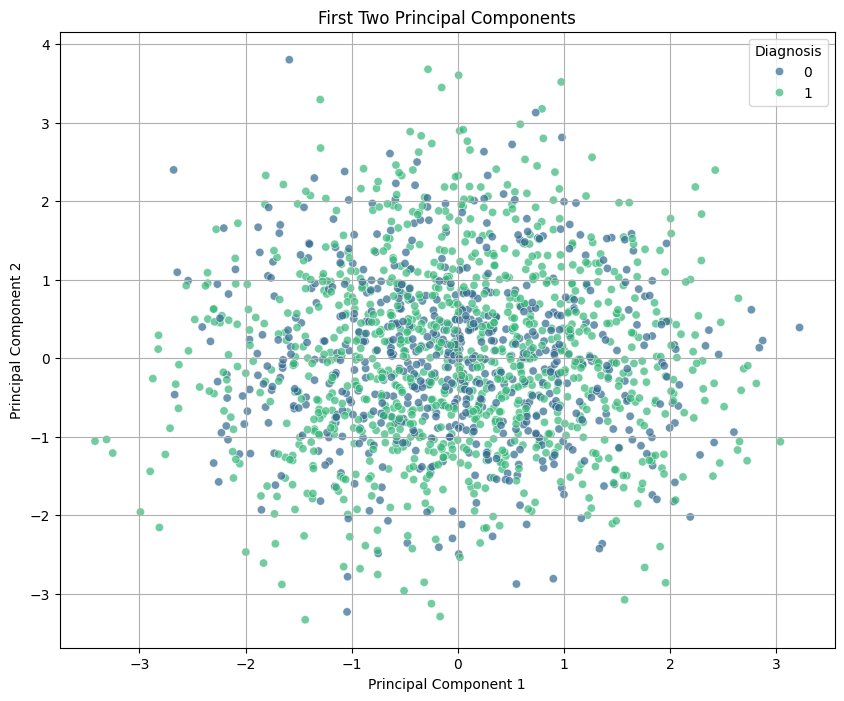

In [ ]:
#PCA
X_train_pca = X_train.copy()
pca = PCA()
X_pca = pca.fit_transform(X_train_pca)


explained_var = pca.explained_variance_ratio_

#  first two principal components
X_pca_2 = pca.transform(X_train_pca)[:, :2]


pca_df = pd.DataFrame(data=X_pca_2, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Diagnosis'] = y_train.reset_index(drop=True)

# Plot the first two principal components
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Diagnosis',
    data=pca_df,
    palette='viridis',
    alpha=0.7
)
plt.title('First Two Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()



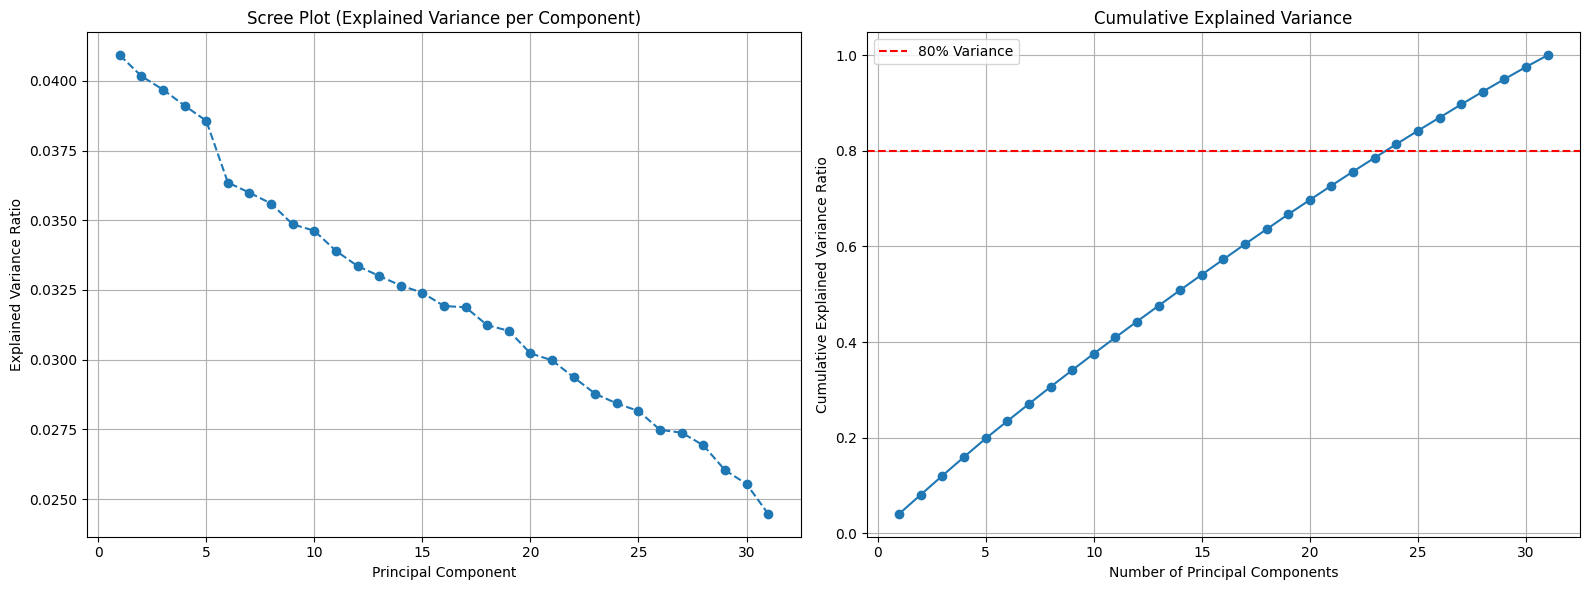

In [ ]:
#explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scree Plot
ax1.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='--')
ax1.set_title('Scree Plot (Explained Variance per Component)')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.grid(True)

# Cumulative Variance
ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
ax2.set_title('Cumulative Explained Variance')
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Explained Variance Ratio')
ax2.axhline(y=0.80, color='r', linestyle='--', label='80% Variance')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


To explain just 80% of the variance in the data, it would take about 24 principal components, therefore PCA would not aid much in dimensionality reduction. Additionally, the data does not separate well with. Due to these factors, coupled with loss of interpretability, principal components will not be utilized further.

In [ ]:
#feature selection using random forest
#as its being used for feature selection we are not evaluating performance but extracting
#feature importances

rfc = RandomForestClassifier(n_estimators=100,random_state=42)

rfc.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

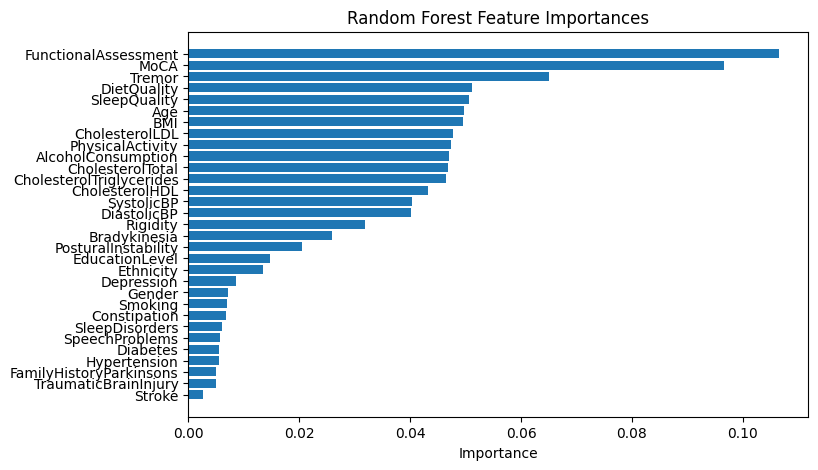

In [ ]:
importances = rfc.feature_importances_

# create DataFrame
feat_imp = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
})

# sort
feat_imp = feat_imp.sort_values(by='importance', ascending=False)

# plot
plt.figure(figsize=(8, 5))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()  # highest importance at top
plt.xlabel("Importance")
plt.title("Random Forest Feature Importances")
plt.show()

In [ ]:
feat_imp

,feature,importance
23,FunctionalAssessment,0.106500
22,MoCA,0.096702
24,Tremor,0.065088
8,DietQuality,0.051212
9,SleepQuality,0.050592
0,Age,0.049676
4,BMI,0.049497
19,CholesterolLDL,0.047713
7,PhysicalActivity,0.047396
6,AlcoholConsumption,0.047024


In [ ]:
feat_imp['cum_importance'] = feat_imp['importance'].cumsum()

feat_imp

,feature,importance,cum_importance
23,FunctionalAssessment,0.106500,0.106500
22,MoCA,0.096702,0.203203
24,Tremor,0.065088,0.268290
8,DietQuality,0.051212,0.319503
9,SleepQuality,0.050592,0.370095
0,Age,0.049676,0.419770
4,BMI,0.049497,0.469268
19,CholesterolLDL,0.047713,0.516981
7,PhysicalActivity,0.047396,0.564377
6,AlcoholConsumption,0.047024,0.611401


In [ ]:
selected_features = feat_imp[
    feat_imp['cum_importance'] <= 0.90
]['feature'].tolist()
selected_features

['FunctionalAssessment',
 'MoCA',
 'Tremor',
 'DietQuality',
 'SleepQuality',
 'Age',
 'BMI',
 'CholesterolLDL',
 'PhysicalActivity',
 'AlcoholConsumption',
 'CholesterolTotal',
 'CholesterolTriglycerides',
 'CholesterolHDL',
 'SystolicBP',
 'DiastolicBP',
 'Rigidity',
 'Bradykinesia']

In [ ]:
X_test_fin.head()

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,CholesterolTriglycerides,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation
194,-0.750559,-0.970737,0.311076,0.743558,-1.610216,-0.651693,-0.937456,1.698334,-0.928595,1.230378,...,1.063465,-1.135687,-0.136990,-0.873699,-0.583750,-0.516835,-0.400723,-0.641535,-0.569122,-0.659100
1879,-0.404866,-0.970737,-0.688642,-0.377437,1.731795,1.534465,-1.182977,-0.964779,0.594393,-0.143414,...,-0.908917,0.413645,1.625785,-0.873699,1.713061,-0.516835,-0.400723,1.558761,-0.569122,1.517221
136,-1.355522,1.030145,-0.688642,-1.498432,-0.379680,-0.651693,0.700988,-0.595346,0.342635,0.035883,...,-0.406435,-1.311961,0.620698,1.144558,-0.583750,1.934855,-0.400723,-0.641535,-0.569122,1.517221
1522,-1.614792,-0.970737,0.311076,-1.498432,1.754671,-0.651693,1.468099,0.290653,-0.684652,-0.286583,...,1.310730,1.574582,-1.218604,-0.873699,-0.583750,1.934855,-0.400723,-0.641535,-0.569122,1.517221
326,0.891484,1.030145,-0.688642,-0.377437,-1.582046,1.534465,-0.374812,-0.102589,0.669840,-0.420464,...,-0.208852,-0.476387,1.657205,1.144558,1.713061,-0.516835,-0.400723,1.558761,-0.569122,-0.659100


In [ ]:
#filtering dropped features out
X_test = X_test_fin[selected_features]

X_test.head()

,FunctionalAssessment,MoCA,Tremor,DietQuality,SleepQuality,Age,BMI,CholesterolLDL,PhysicalActivity,AlcoholConsumption,CholesterolTotal,CholesterolTriglycerides,CholesterolHDL,SystolicBP,DiastolicBP,Rigidity,Bradykinesia
194,-0.136990,-1.135687,-0.873699,-0.928595,1.230378,-0.750559,-1.610216,1.118380,1.698334,-0.937456,0.984016,1.063465,1.683402,-1.196884,-1.467067,-0.583750,-0.516835
1879,1.625785,0.413645,-0.873699,0.594393,-0.143414,-0.404866,1.731795,1.381698,-0.964779,-1.182977,-0.844673,-0.908917,-1.670738,-0.056909,-0.059318,1.713061,-0.516835
136,0.620698,-1.311961,1.144558,0.342635,0.035883,-1.355522,-0.379680,-1.596390,-0.595346,0.700988,-1.725391,-0.406435,-0.879574,-0.550898,-0.000662,-0.583750,1.934855
1522,-1.218604,1.574582,-0.873699,-0.684652,-0.286583,-1.614792,1.754671,1.639407,0.290653,1.468099,-1.409935,1.310730,-1.455043,-0.930890,1.524399,-0.583750,1.934855
326,1.657205,-0.476387,1.144558,0.669840,-0.420464,0.891484,-1.582046,-0.752723,-0.102589,-0.374812,1.410975,-0.208852,-1.228963,0.817073,-1.467067,1.713061,-0.516835


In [ ]:
X_train = X_train[selected_features]
X_train.head()

,FunctionalAssessment,MoCA,Tremor,DietQuality,SleepQuality,Age,BMI,CholesterolLDL,PhysicalActivity,AlcoholConsumption,CholesterolTotal,CholesterolTriglycerides,CholesterolHDL,SystolicBP,DiastolicBP,Rigidity,Bradykinesia
1700,1.167276,0.754879,-0.873699,0.784252,1.036426,-1.182675,1.518932,1.374462,0.009098,0.768291,-0.283215,-0.449776,1.637062,1.501058,1.524399,-0.583750,-0.516835
1102,-1.662296,-0.839814,1.144558,-1.039368,-0.471761,1.237178,0.926410,0.106169,1.496181,0.969844,-1.332531,0.143216,-1.315257,-0.854891,-1.701691,-0.583750,-0.516835
508,0.352029,0.320770,-0.873699,-1.177827,0.895068,-1.441945,0.406023,1.396466,0.319099,-0.722797,1.474048,1.165532,-0.817251,1.045068,1.465743,-0.583750,-0.516835
679,0.285203,1.579368,-0.873699,1.391411,-0.371378,1.582871,-1.000766,1.517250,1.631347,-0.480765,-1.188203,1.490209,-0.903104,-0.436900,-1.525723,1.713061,-0.516835
1000,-1.023176,1.677038,1.144558,1.345225,-1.325735,0.632214,0.748667,-0.179033,-0.573692,-0.705950,0.106813,1.592260,-1.170761,-0.778893,-1.291098,1.713061,1.934855


## Modeling

### Preprocessing Summary

There were no null values or outliers in both the continuous and categorical columns. Boxplots, countplots and a correlation matrix were constructed to explore the relationships between the predictors and outcome.

The data was split into train and test sets, using a stratified split due to class imbalance, and scaled. The test set was strictly set aside for use only at the end stages when comparing how the best models of each type would perform on unseen data. More exploration was done on the training set with logistic regression (single and all predictors, polynomial, interactions), and PCA (principal component analysis). PCA did not aid with dimensionality reduction and did not separate the data well.

For feature selection, feature importances were extracted from a random forest classifier. Features were then ranked from most to least important and those contributing to about 90% of cumulative importance were chosen for the official modeling stage.

### Modeling Approach

With the chosen features, a mixture of parametric and non-parametric methods were tested:
* Logistic Regression
* Linear Discriminant Analysis
* Quadratic Discriminant Analysis
* Naive Bayes Classifier
* K-Nearest Neighbors
* Random Forest Classifiers
* Gradient Boosting Classifiers
* XGBoost
* Support Vector Machines

Metrics evaluated included accuracy, f-1 score, precision, roc-auc, and recall.

Recall was the key metric being optimized for in Grid Search cross validation, as a key aim with diagnosis is to minimize false negatives.

### Models

In [ ]:
#logistic

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),
    param_grid=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)



grid.fit(X_train, y_train)


print("Best hyperparameters:", grid.best_params_)
print("CV recall (best model):", round(grid.best_score_, 4))
best_idx = grid.best_index_
std = grid.cv_results_['std_test_score'][best_idx]
print(f"standard deviation:  {std:.3f} ")

Best hyperparameters: {'C': 0.01, 'penalty': 'l2'}
CV recall (best model): 0.6874
standard deviation:  0.016 



 Test Performance 
Accuracy: 0.6888361045130641
Precision: 0.7927927927927928
Recall: 0.6743295019157088
F1-score: 0.7287784679089027
AUC: 0.7826628352490421


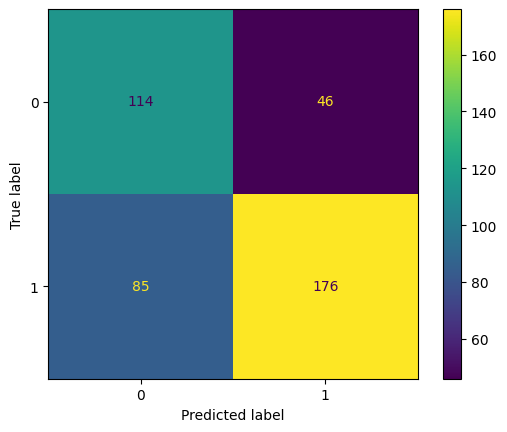

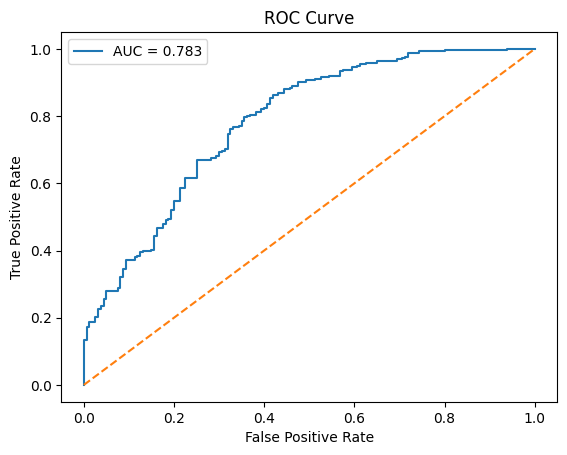

In [ ]:
#final model (fit on full training set)
best_logreg = grid.best_estimator_
best_logreg.fit(X_train, y_train)


y_pred = best_logreg.predict(X_test)
y_prob_lr = best_logreg.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)
# tn, fp, fn, tp = cm
# specificity = tn / (tn + fp)

auc_lr = roc_auc_score(y_test, y_prob_lr)

print("\n Test Performance ")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("AUC:", auc_lr)
# print("\nConfusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f"AUC = {auc_lr:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#lda

In [ ]:
lda = LDA()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# 2. Cross-validation (recall)
# -----------------------------
cv_recall = cross_val_score(
    lda,
    X_train,
    y_train,
    cv=cv,
    scoring='recall'
)

print("CV Recall Scores:", cv_recall)
print("Mean CV Recall:", cv_recall.mean())
print("Standard Deviation:", cv_recall.std())

CV Recall Scores: [0.86057692 0.79904306 0.87559809 0.80861244 0.83653846]
Mean CV Recall: 0.8360737946264262
Standard Deviation: 0.029285457035843475



 Test Performance
Accuracy: 0.7434679334916865
Precision: 0.7722419928825622
Recall: 0.8314176245210728
F1-score: 0.8007380073800738
AUC: 0.7832614942528735

Confusion Matrix:
 [[ 96  64]
 [ 44 217]]


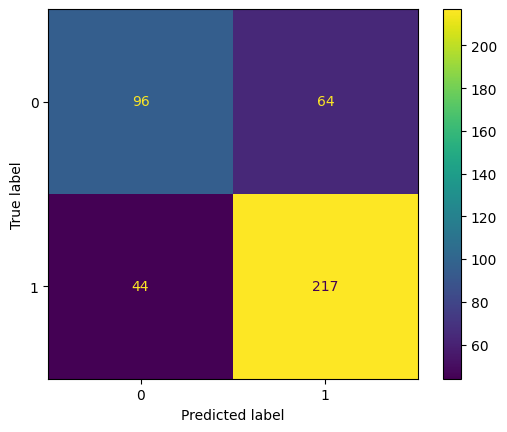

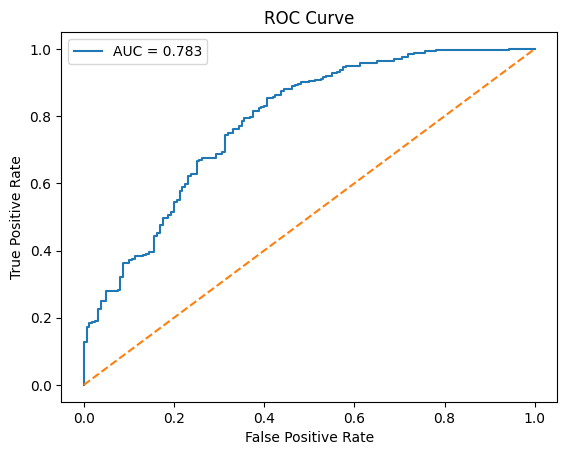

In [ ]:
lda.fit(X_train, y_train)


y_pred = lda.predict(X_test)
y_prob_lda = lda.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

auc_lda = roc_auc_score(y_test, y_prob_lda)

print("\n Test Performance")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("AUC:", auc_lda)
print("\nConfusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

#roc
fpr_lda, tpr_lda, _ = roc_curve(y_test, y_prob_lda)

plt.figure()
plt.plot(fpr_lda, tpr_lda, label=f"AUC = {auc_lda:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#qda
qda = QDA()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


cv_recall = cross_val_score(
    qda,
    X_train,
    y_train,
    cv=cv,
    scoring='recall'
)
print("CV Recall Scores:", cv_recall)
print("Mean CV Recall:", cv_recall.mean())
print("Standard Deviation:", cv_recall.std())

CV Recall Scores: [0.80288462 0.76076555 0.84210526 0.80861244 0.78846154]
Mean CV Recall: 0.8005658814869341
Standard Deviation: 0.02655645063249708



 Test 
Accuracy: 0.7339667458432304
Precision: 0.7749077490774908
Recall: 0.8045977011494253
F1-score: 0.7894736842105263
AUC: 0.7776340996168581

Confusion Matrix:
 [[ 99  61]
 [ 51 210]]


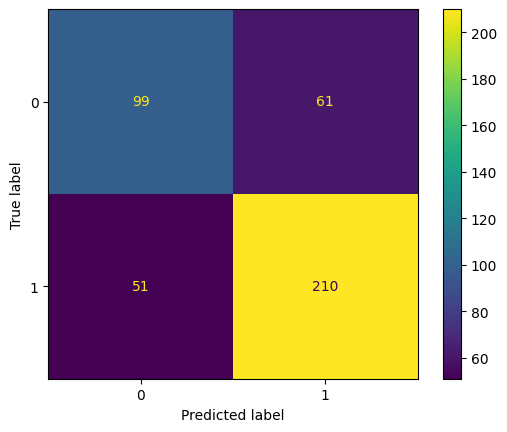

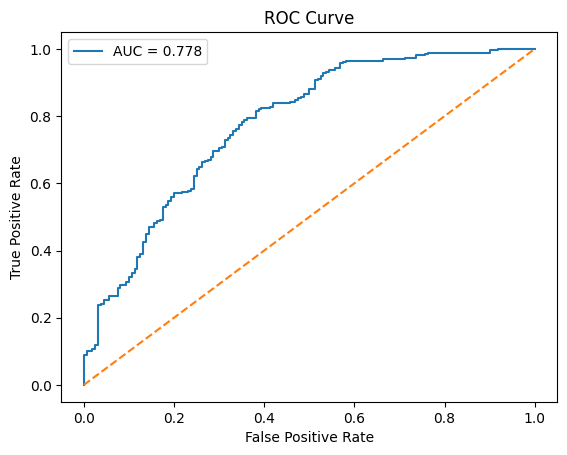

In [ ]:
qda.fit(X_train, y_train)


y_pred = qda.predict(X_test)
y_prob_qda = qda.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)


auc_qda = roc_auc_score(y_test, y_prob_qda)

print("\n Test ")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

print("F1-score:", f1)
print("AUC:", auc_qda)
print("\nConfusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


fpr_qda, tpr_qda, _ = roc_curve(y_test, y_prob_qda)

plt.figure()
plt.plot(fpr_qda, tpr_qda, label=f"AUC = {auc_qda:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#naivebayes

In [ ]:
nb = GaussianNB()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


cv_recall = cross_val_score(
    nb,
    X_train,
    y_train,
    cv=cv,
    scoring='recall'
)

print("CV Recall Scores:", cv_recall)
print("Mean CV Recall:", cv_recall.mean())
print("Standard Deviation:", cv_recall.std())

CV Recall Scores: [0.82692308 0.77990431 0.8708134  0.78947368 0.80288462]
Mean CV Recall: 0.8139998159735
Standard Deviation: 0.03250346531074809



Test
Accuracy: 0.7197149643705463
Precision: 0.7638376383763837
Recall: 0.7931034482758621
F1-score: 0.7781954887218046
AUC: 0.7871647509578543

Confusion Matrix:
 [[ 96  64]
 [ 54 207]]


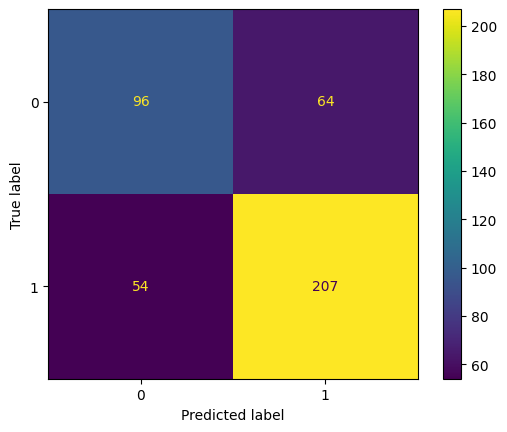

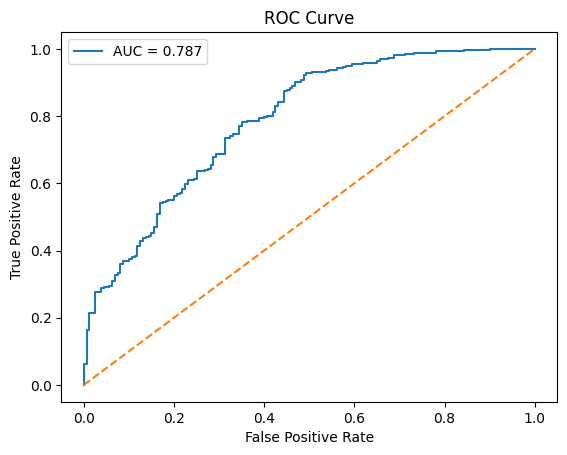

In [ ]:
nb.fit(X_train, y_train)


y_pred = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1]


# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)


auc_nb = roc_auc_score(y_test, y_prob_nb)

print("\nTest")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

print("F1-score:", f1)
print("AUC:", auc_nb)
print("\nConfusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)

plt.figure()
plt.plot(fpr_nb, tpr_nb, label=f"AUC = {auc_nb:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#knn
param_grid = {
    'n_neighbors': list(range(1,26,2)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=param_grid,
    cv=cv,
    scoring='recall'
)

grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
print("CV recall (best model):", round(grid.best_score_, 4))
best_idx = grid.best_index_
std = grid.cv_results_['std_test_score'][best_idx]
print(f"standard deviation:  {std:.3f} ")

Best hyperparameters: {'n_neighbors': 23, 'p': 1, 'weights': 'uniform'}
CV recall (best model): 0.86
standard deviation:  0.010 



Test
Accuracy: 0.7410926365795725
Precision: 0.7467532467532467
Recall: 0.8812260536398467
F1-score: 0.8084358523725835
AUC: 0.7516642720306513

Confusion Matrix:
 [[ 82  78]
 [ 31 230]]


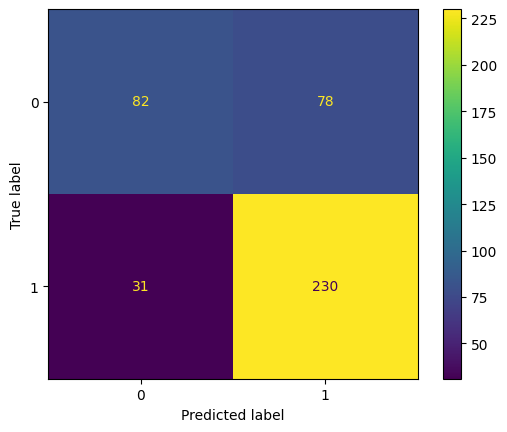

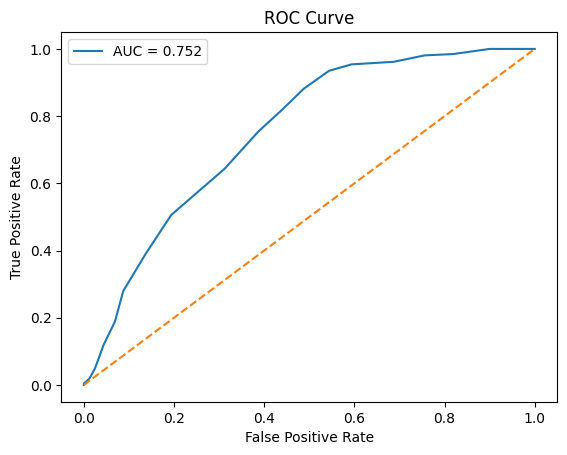

In [ ]:
best_knn = grid.best_estimator_
best_knn.fit(X_train, y_train)


y_pred = best_knn.predict(X_test)
y_prob_knn = best_knn.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)


auc_knn = roc_auc_score(y_test, y_prob_knn)

print("\nTest")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

print("F1-score:", f1)
print("AUC:", auc_knn)
print("\nConfusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# roc
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

plt.figure()
plt.plot(fpr_knn, tpr_knn, label=f"AUC = {auc_knn:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#randomforest
param_grid = {'n_estimators': np.arange(100, 500, 100),
              'min_samples_split': np.arange(5, 30, 5),
              'max_depth': np.arange(2,7)}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    param_grid=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
#print("CV accuracy (best model):", grid.best_score_)
print("CV recall (best model):", round(grid.best_score_, 4))
best_idx = grid.best_index_
std = grid.cv_results_['std_test_score'][best_idx]
print(f"standard deviation:  {std:.3f} ")

Best hyperparameters: {'max_depth': np.int64(6), 'min_samples_split': np.int64(5), 'n_estimators': np.int64(400)}
CV recall (best model): 0.8658
standard deviation:  0.025 



Test
Accuracy: 0.7790973871733967
Precision: 0.7978723404255319
Recall: 0.8620689655172413
F1-score: 0.8287292817679558
AUC: 0.8002634099616859

Confusion Matrix:
 [[103  57]
 [ 36 225]]


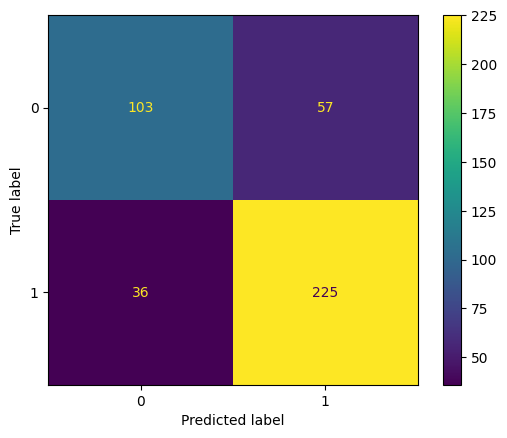

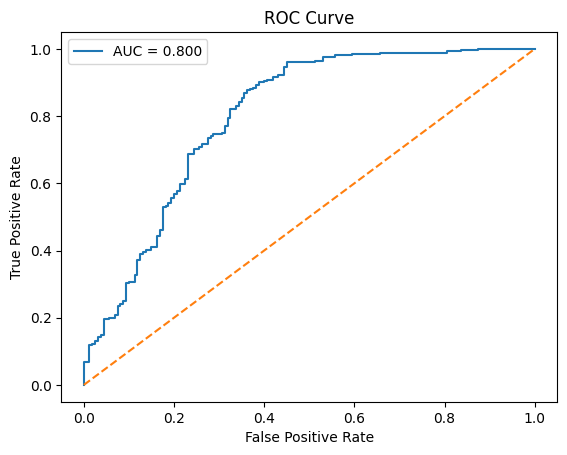

In [ ]:
# final model
best_rf = grid.best_estimator_
best_rf.fit(X_train, y_train)


#Test
y_pred = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

auc_rf = roc_auc_score(y_test, y_prob_rf)

print("\nTest")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

print("F1-score:", f1)
print("AUC:", auc_rf)
print("\nConfusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# roc
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure()
plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#xgboost
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ),
    param_grid=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
#print("Best CV recall:", grid.best_score_)
print("CV recall (best model):", round(grid.best_score_, 4))
best_idx = grid.best_index_
std = grid.cv_results_['std_test_score'][best_idx]
print(f"standard deviation:  {std:.3f} ")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:29:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}
CV recall (best model): 0.953
standard deviation:  0.015 


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:29:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Test
Accuracy: 0.7980997624703088
Precision: 0.7732919254658385
Recall: 0.9540229885057471
F1-score: 0.8542024013722127
AUC: 0.7869971264367817

Confusion Matrix:
 [[ 87  73]
 [ 12 249]]


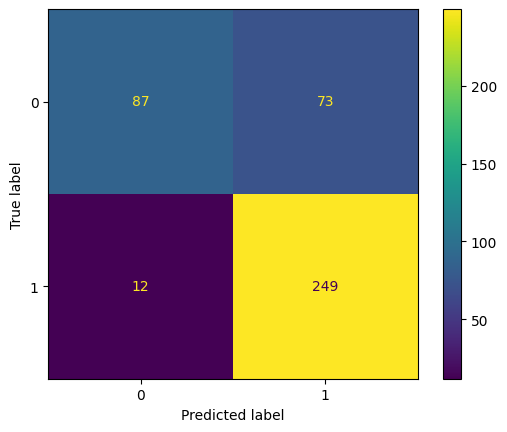

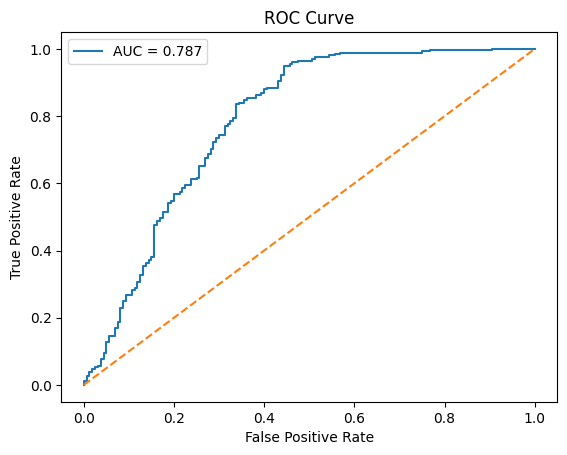

In [ ]:
best_xgb = grid.best_estimator_

best_xgb.fit(X_train, y_train)

y_pred = best_xgb.predict(X_test)
y_prob_xg = best_xgb.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)


auc_xg = roc_auc_score(y_test, y_prob_xg)

print("\nTest")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

print("F1-score:", f1)
print("AUC:", auc_xg)
print("\nConfusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

#roc
fpr_xg, tpr_xg, _ = roc_curve(y_test, y_prob_xg)

plt.figure()
plt.plot(fpr_xg, tpr_xg, label=f"AUC = {auc_xg:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#gradientboosting

In [ ]:
param_grid = {'n_estimators': np.arange(100, 500, 100),
              'learning_rate':[0.01, 0.05, 0.1, 0.2, 0.3],
              'max_depth': np.arange(2,7)}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
#print("CV recall (best model):", grid.best_score_)
print("CV recall (best model):", round(grid.best_score_, 4))
best_idx = grid.best_index_
std = grid.cv_results_['std_test_score'][best_idx]
print(f"standard deviation:  {std:.3f} ")


Best hyperparameters: {'learning_rate': 0.01, 'max_depth': np.int64(3), 'n_estimators': np.int64(100)}
CV recall (best model): 0.9444
standard deviation:  0.016 



Test
Accuracy: 0.7909738717339667
Precision: 0.7711598746081505
Recall: 0.9425287356321839
F1-score: 0.8482758620689655
AUC: 0.7976173371647509

Confusion Matrix:
 [[ 87  73]
 [ 15 246]]


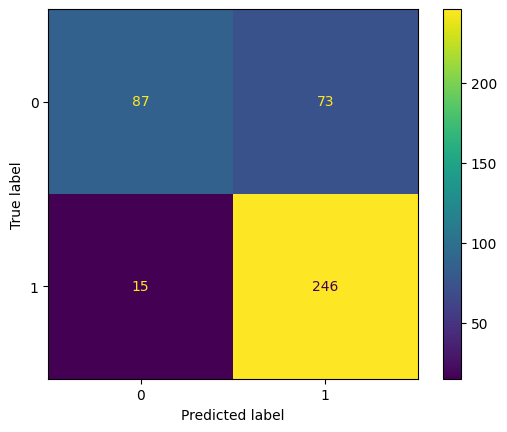

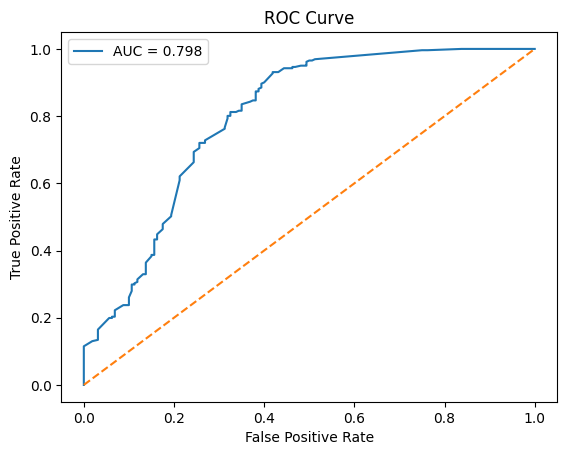

In [ ]:
# final model
best_gb = grid.best_estimator_
best_gb.fit(X_train, y_train)

# test
y_pred = best_gb.predict(X_test)
y_prob_gb = best_gb.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)


auc_gb = roc_auc_score(y_test, y_prob_gb)

print("\nTest")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

print("F1-score:", f1)
print("AUC:", auc_gb)
print("\nConfusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# roc
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure()
plt.plot(fpr_gb, tpr_gb, label=f"AUC = {auc_gb:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#svm



In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 'scale'],
    'kernel': ['rbf']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    SVC(
        probability=True,
        class_weight='balanced'
    ),
    param_grid=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
#print("CV recall (best model):", grid.best_score_)
print("CV recall (best model):", round(grid.best_score_, 4))
best_idx = grid.best_index_
std = grid.cv_results_['std_test_score'][best_idx]
print(f"standard deviation:  {std:.3f} ")

Best hyperparameters: {'C': 1, 'gamma': 1, 'kernel': 'rbf'}
CV recall (best model): 1.0
standard deviation:  0.000 



Test
Accuracy: 0.6199524940617577
Precision: 0.6199524940617577
Recall: 1.0
F1-score: 0.7653958944281525
AUC: 0.32310823754789275

Confusion Matrix:
 [[  0 160]
 [  0 261]]


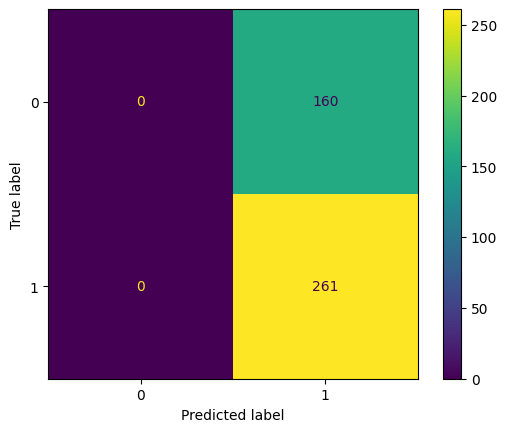

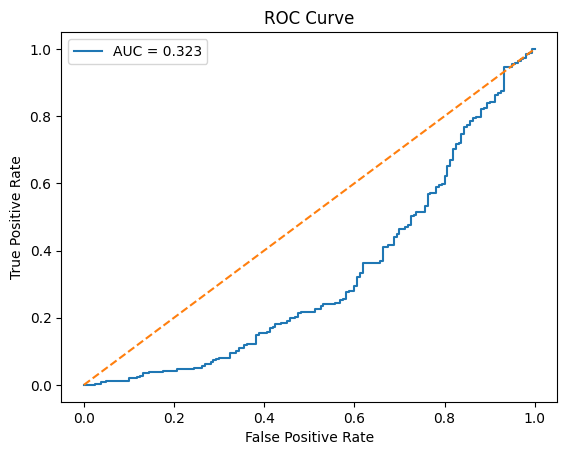

In [ ]:
# final model
best_svm = grid.best_estimator_
best_svm.fit(X_train, y_train)

# test
y_pred = best_svm.predict(X_test)
y_prob_svmr = best_svm.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

auc_svmr = roc_auc_score(y_test, y_prob_svmr)

print("\nTest")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

print("F1-score:", f1)
print("AUC:", auc_svmr)
print("\nConfusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

#roc
fpr_svmr, tpr_svmr, _ = roc_curve(y_test, y_prob_svmr)

plt.figure()
plt.plot(fpr_svmr, tpr_svmr, label=f"AUC = {auc_svmr:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#linear kernel svm
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 'scale'],
    'kernel': ['linear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    SVC(
        probability=True,
        class_weight='balanced'
    ),
    param_grid=param_grid,
    cv=cv,
    scoring='recall',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
print("CV recall (best model):", round(grid.best_score_, 4))
best_idx = grid.best_index_
std = grid.cv_results_['std_test_score'][best_idx]
print(f"standard deviation:  {std:.3f} ")

Best hyperparameters: {'C': 10, 'gamma': 0.01, 'kernel': 'linear'}
CV recall (best model): 0.7066
standard deviation:  0.020 



 Test
Accuracy: 0.7054631828978623
Precision: 0.7965367965367965
Recall: 0.7049808429118773
F1-score: 0.7479674796747967
AUC: 0.7846144636015325

Confusion Matrix:
 [[113  47]
 [ 77 184]]


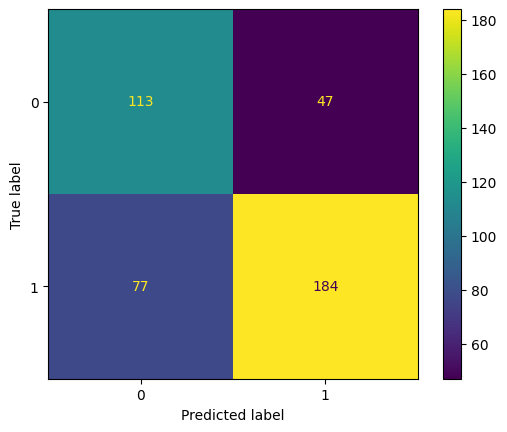

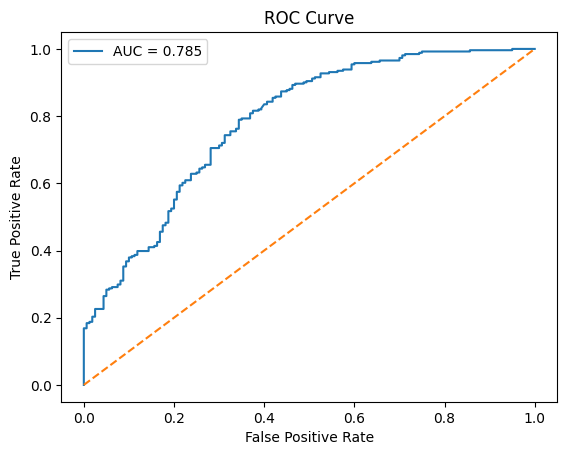

In [ ]:
# final model
best_svm = grid.best_estimator_
best_svm.fit(X_train, y_train)

# test
y_pred = best_svm.predict(X_test)
y_prob_svml = best_svm.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

auc_svml = roc_auc_score(y_test, y_prob_svml)

print("\n Test")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

print("F1-score:", f1)
print("AUC:", auc_svml)
print("\nConfusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

#roc
fpr_svml, tpr_svml, _ = roc_curve(y_test, y_prob_svml)

plt.figure()
plt.plot(fpr_svml, tpr_svml, label=f"AUC = {auc_svml:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
#changing metric svm radial kernel to f1 to check if improves radial kernel poor performance

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.01, 0.1, 1, 'scale'],
    'kernel': ['rbf']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    SVC(
        probability=True,
        class_weight='balanced'
    ),
    param_grid=param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
print("CV recall (best model):", round(grid.best_score_, 4))
best_idx = grid.best_index_
std = grid.cv_results_['std_test_score'][best_idx]
print(f"standard deviation:  {std:.3f} ")

Best hyperparameters: {'C': 0.1, 'gamma': 0.1, 'kernel': 'rbf'}
CV recall (best model): 0.7865
standard deviation:  0.028 



Test
Accuracy: 0.7529691211401425
Precision: 0.7833935018050542
Recall: 0.8314176245210728
F1-score: 0.8066914498141264
AUC: 0.7759099616858236

Confusion Matrix:
 [[100  60]
 [ 44 217]]


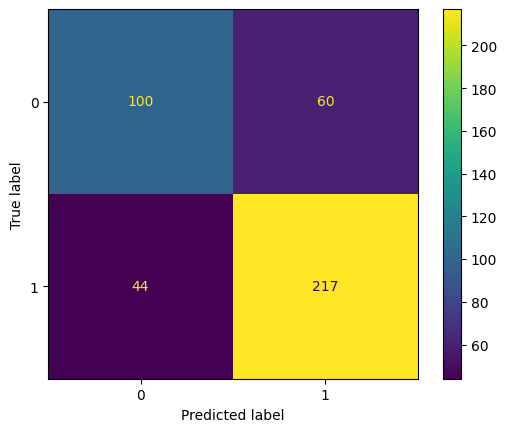

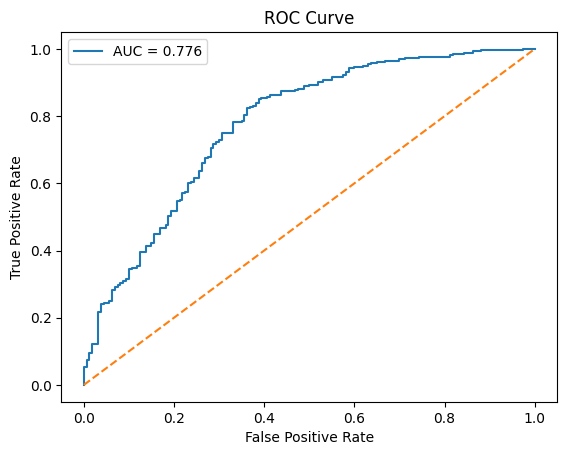

In [ ]:
# final model
best_svm = grid.best_estimator_
best_svm.fit(X_train, y_train)

#test
y_pred = best_svm.predict(X_test)
y_prob_svmrf1 = best_svm.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)


auc_svmrf1 = roc_auc_score(y_test, y_prob_svmrf1)

print("\nTest")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)
print("AUC:", auc_svmrf1)
print("\nConfusion Matrix:\n", cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

# roc
fpr_svmrf1, tpr_svmrf1, _ = roc_curve(y_test, y_prob_svmrf1)

plt.figure()
plt.plot(fpr_svmrf1, tpr_svmrf1, label=f"AUC = {auc_svmrf1:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

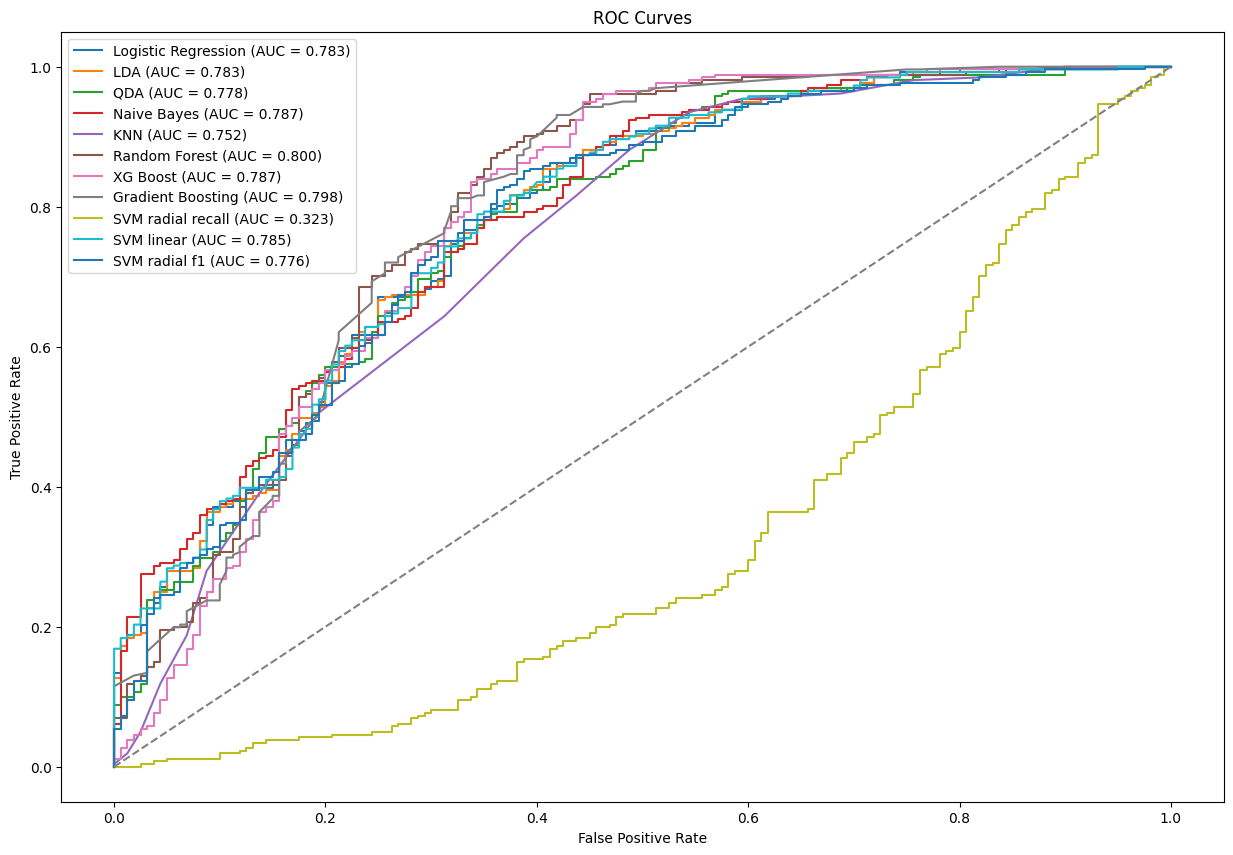

In [ ]:
#plot of all roc curves

#logistic regression

#lda

#qda

#nb

#knn

#rf

#xgboost

#gradientboosting

#svm radial kernel

#svm radial kernel (change from recall to f1 for )

#svm linear kernel


plt.figure(figsize=(15,10))

tags_fpr = ["fpr_lr", "fpr_lda", "fpr_qda", "fpr_nb", "fpr_knn", "fpr_rf", "fpr_xg", "fpr_gb", "fpr_svmr", "fpr_svml", "fpr_svmrf1"]
tags_tpr = ["tpr_lr", "tpr_lda", "tpr_qda", "tpr_nb", "tpr_knn", "tpr_rf", "tpr_xg", "tpr_gb", "tpr_svmr", "tpr_svml", "tpr_svmrf1"]
tags_auc =["auc_lr", "auc_lda", "auc_qda", "auc_nb", "auc_knn", "auc_rf", "auc_xg", "auc_gb", "auc_svmr", "auc_svml", "auc_svmrf1"]
tags_labels = ["Logistic Regression", "LDA", "QDA", "Naive Bayes", "KNN", "Random Forest", "XG Boost", "Gradient Boosting", "SVM radial recall", "SVM linear", "SVM radial f1"]

for i in range(len(tags_fpr)):
    fpr = eval(tags_fpr[i])
    tpr = eval(tags_tpr[i])
    auc = eval(tags_auc[i])
    plt.plot(fpr, tpr, label=f'{tags_labels[i]} (AUC = {auc:.3f})')

#random classify line
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()


# Summary and Conclusion

## Summary table of models

The best performing model was XGBoost, with a recall of 96.4%, f1 score of 85.42%

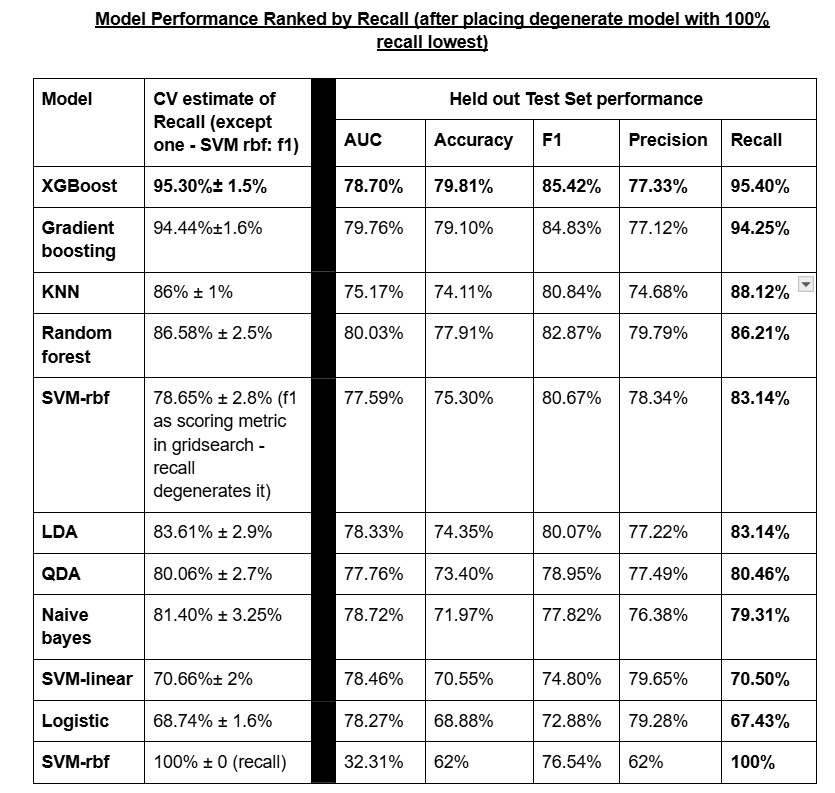

## Conclusion

The main aim was to optimize for recall while maintaining a relatively good balance with the other metrics. The model that performed best, with the highest recall (95.4 %), accuracy (79.81%), and f1-score (85.42%) on unseen test data was the XGBoost model. Its precision and AUC were still in the ballpark (± 2%) of the highest scores in these two areas.

Generally, flexible, non-parametric methods worked best on the given dataset. Ensemble tree methods performed the best, and linear methods the worst. This suggested a complex boundary. Although flexible approaches generally dominated the top spots, SVM with a radial kernel did not work well initially. It resulted in a degenerate model with 100% recall and all other metrics poor. Attempting f-1 as the scoring metric with the radial kernel resulted in a more balanced model, but it scored lowest among the flexible methods. The radial kernel in SVM can result in a degenerate model if metrics such as recall or precision are directly used for scoring in the grid-search; it benefits from inherently balanced metrics such as f-1.

To improve the performance of SVM, other approaches could be optimizing for recall still but changing the decision threshold, or carefully constraining the values of gamma and c in the hyperparameter grid. For other models, expanding the hyperparameter tuning search space could aid in better results. For logistic  regression, more models with nonlinear predictors and interaction terms could be tested.To generally improve predictive accuracy for this problem, different feature selection methods can also be attempted, and Neural Networks can be explored.
